# Genesis Demonstrator Dataset — Exploration & Visualization

## Dataset Overview

The **Genesis Demonstrator Dataset** originates from a **pick-and-place demonstrator** — a physical smart manufacturing system that sorts metal and non-metal workpieces. It was designed specifically for benchmarking anomaly detection and process monitoring in Industry 4.0/5.0 settings.

### Key Characteristics
| Property | Value |
|---|---|
| **Source** | Physical pick-and-place demonstrator (real sensor data) |
| **Total Samples** | ~16,220 |
| **Dimensions** | 18 sensor/actuator variables |
| **Files** | Normal, AnomalyLabels, StateMachineLabel, LinearDrive, Pressure |
| **Labels** | Anomaly labels + State machine labels (operational phases) |
| **Domain** | Smart Manufacturing / Industrial Control |

### Research Relevance for Industry 5.0
- **Anomaly Detection**: Labeled anomalies from real physical faults (linear drive and pressure anomalies)
- **Clustering**: State machine labels define distinct operational phases — perfect for TICC-style clustering
- **Predictive Maintenance**: Physical degradation patterns in actuator data
- **Smart Manufacturing**: Direct Industry 5.0 relevance — human-robot collaboration in production


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = 'genesis'

# Load all files
normal = pd.read_csv(f'{DATA_DIR}/Genesis_normal.csv')
anomaly_labels = pd.read_csv(f'{DATA_DIR}/Genesis_AnomalyLabels.csv')
state_labels = pd.read_csv(f'{DATA_DIR}/Genesis_StateMachineLabel.csv')
lineardrive = pd.read_csv(f'{DATA_DIR}/Genesis_lineardrive.csv')
pressure = pd.read_csv(f'{DATA_DIR}/Genesis_pressure.csv')

print("=== Genesis Dataset Files ===")
print(f"Normal operation: {normal.shape} — {list(normal.columns[:5])}...")
print(f"Anomaly Labels: {anomaly_labels.shape} — columns: {list(anomaly_labels.columns[:5])}...")
print(f"State Machine Labels: {state_labels.shape}")
print(f"Linear Drive anomalies: {lineardrive.shape}")
print(f"Pressure anomalies: {pressure.shape}")


=== Genesis Dataset Files ===
Normal operation: (7040, 24) — ['Timestamp', 'MotorData.ActCurrent', 'MotorData.ActSpeed', 'MotorData.IsAcceleration', 'MotorData.IsForce']...
Anomaly Labels: (16220, 20) — columns: ['Timestamp', 'Label', 'MotorData.ActCurrent', 'MotorData.ActPosition', 'MotorData.ActSpeed']...
State Machine Labels: (16220, 20)
Linear Drive anomalies: (7424, 24)
Pressure anomalies: (8476, 24)


In [2]:
# Explore the data structure
print("=== Normal Data Columns ===")
for i, col in enumerate(normal.columns):
    print(f"  {i}: {col}")
print(f"\n=== Anomaly Labels Columns ===")
for i, col in enumerate(anomaly_labels.columns):
    print(f"  {i}: {col}")
print(f"\nUnique anomaly labels: {anomaly_labels['Label'].unique()}")
print(f"Unique state labels: {state_labels['Label'].unique()}")


=== Normal Data Columns ===
  0: Timestamp
  1: MotorData.ActCurrent
  2: MotorData.ActSpeed
  3: MotorData.IsAcceleration
  4: MotorData.IsForce
  5: MotorData.Motor_Pos1reached
  6: MotorData.Motor_Pos2reached
  7: MotorData.Motor_Pos3reached
  8: MotorData.Motor_Pos4reached
  9: MotorData.SetAcceleration
  10: MotorData.SetCurrent
  11: MotorData.SetForce
  12: MotorData.SetSpeed
  13: NVL_Recv_Ind.GL_Metall
  14: NVL_Recv_Ind.GL_NonMetall
  15: NVL_Recv_Storage.GL_I_ProcessStarted
  16: NVL_Recv_Storage.GL_I_Slider_IN
  17: NVL_Recv_Storage.GL_I_Slider_OUT
  18: NVL_Recv_Storage.GL_LightBarrier
  19: NVL_Send_Storage.ActivateStorage
  20: PLC_PRG.Gripper
  21: PLC_PRG.MaterialIsMetal
  22: NVL_Recv_Storage.GL_X_TimeSlideIn
  23: NVL_Recv_Storage.GL_X_TimeSlideOut

=== Anomaly Labels Columns ===
  0: Timestamp
  1: Label
  2: MotorData.ActCurrent
  3: MotorData.ActPosition
  4: MotorData.ActSpeed
  5: MotorData.IsAcceleration
  6: MotorData.IsForce
  7: MotorData.Motor_Pos1reached
 

## 1. Normal Operation — Multivariate Time Series Overview

The normal operation data captures the pick-and-place cycle: the system picks up workpieces, identifies them (metal vs non-metal), and places them in the correct storage location. Each cycle involves motor movements, gripper operations, and sensor readings.


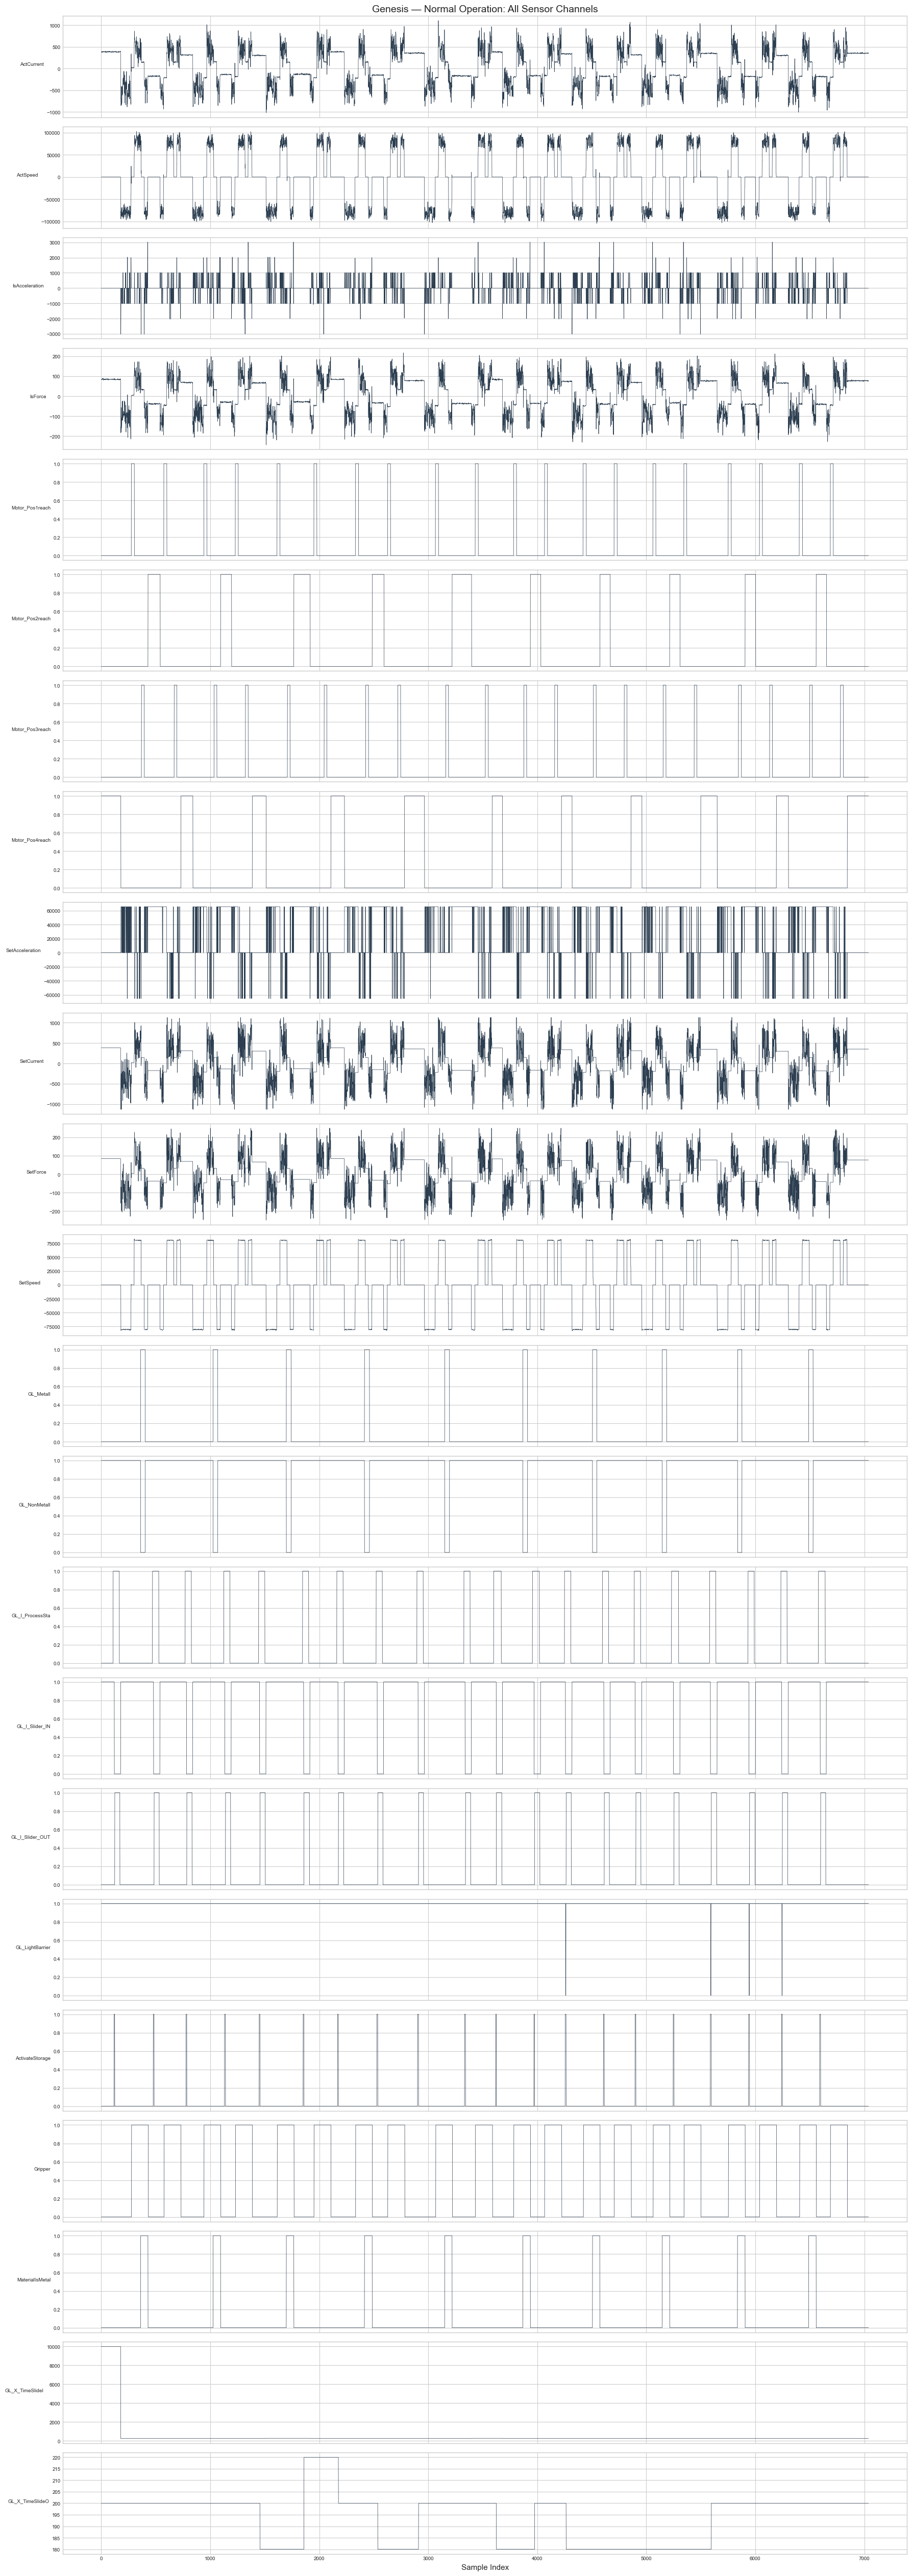

Normal data: 7040 samples, 23 sensor channels


In [3]:
# Visualize normal operation data
sensor_cols = [c for c in normal.columns if c != 'Timestamp']

fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(18, 2.2 * len(sensor_cols)), sharex=True)

for i, col in enumerate(sensor_cols):
    axes[i].plot(range(len(normal)), normal[col].values, linewidth=0.5, color='#2c3e50')
    axes[i].set_ylabel(col.split('.')[-1][:15], fontsize=7, rotation=0, ha='right')
    axes[i].tick_params(labelsize=7)

axes[-1].set_xlabel('Sample Index')
axes[0].set_title('Genesis — Normal Operation: All Sensor Channels', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Normal data: {len(normal)} samples, {len(sensor_cols)} sensor channels")


## 2. State Machine Labels — Operational Phase Clustering

The state machine labels identify **distinct operational phases** of the pick-and-place cycle. These phases represent the ground truth for **time series clustering** — each segment belongs to a specific operational state.


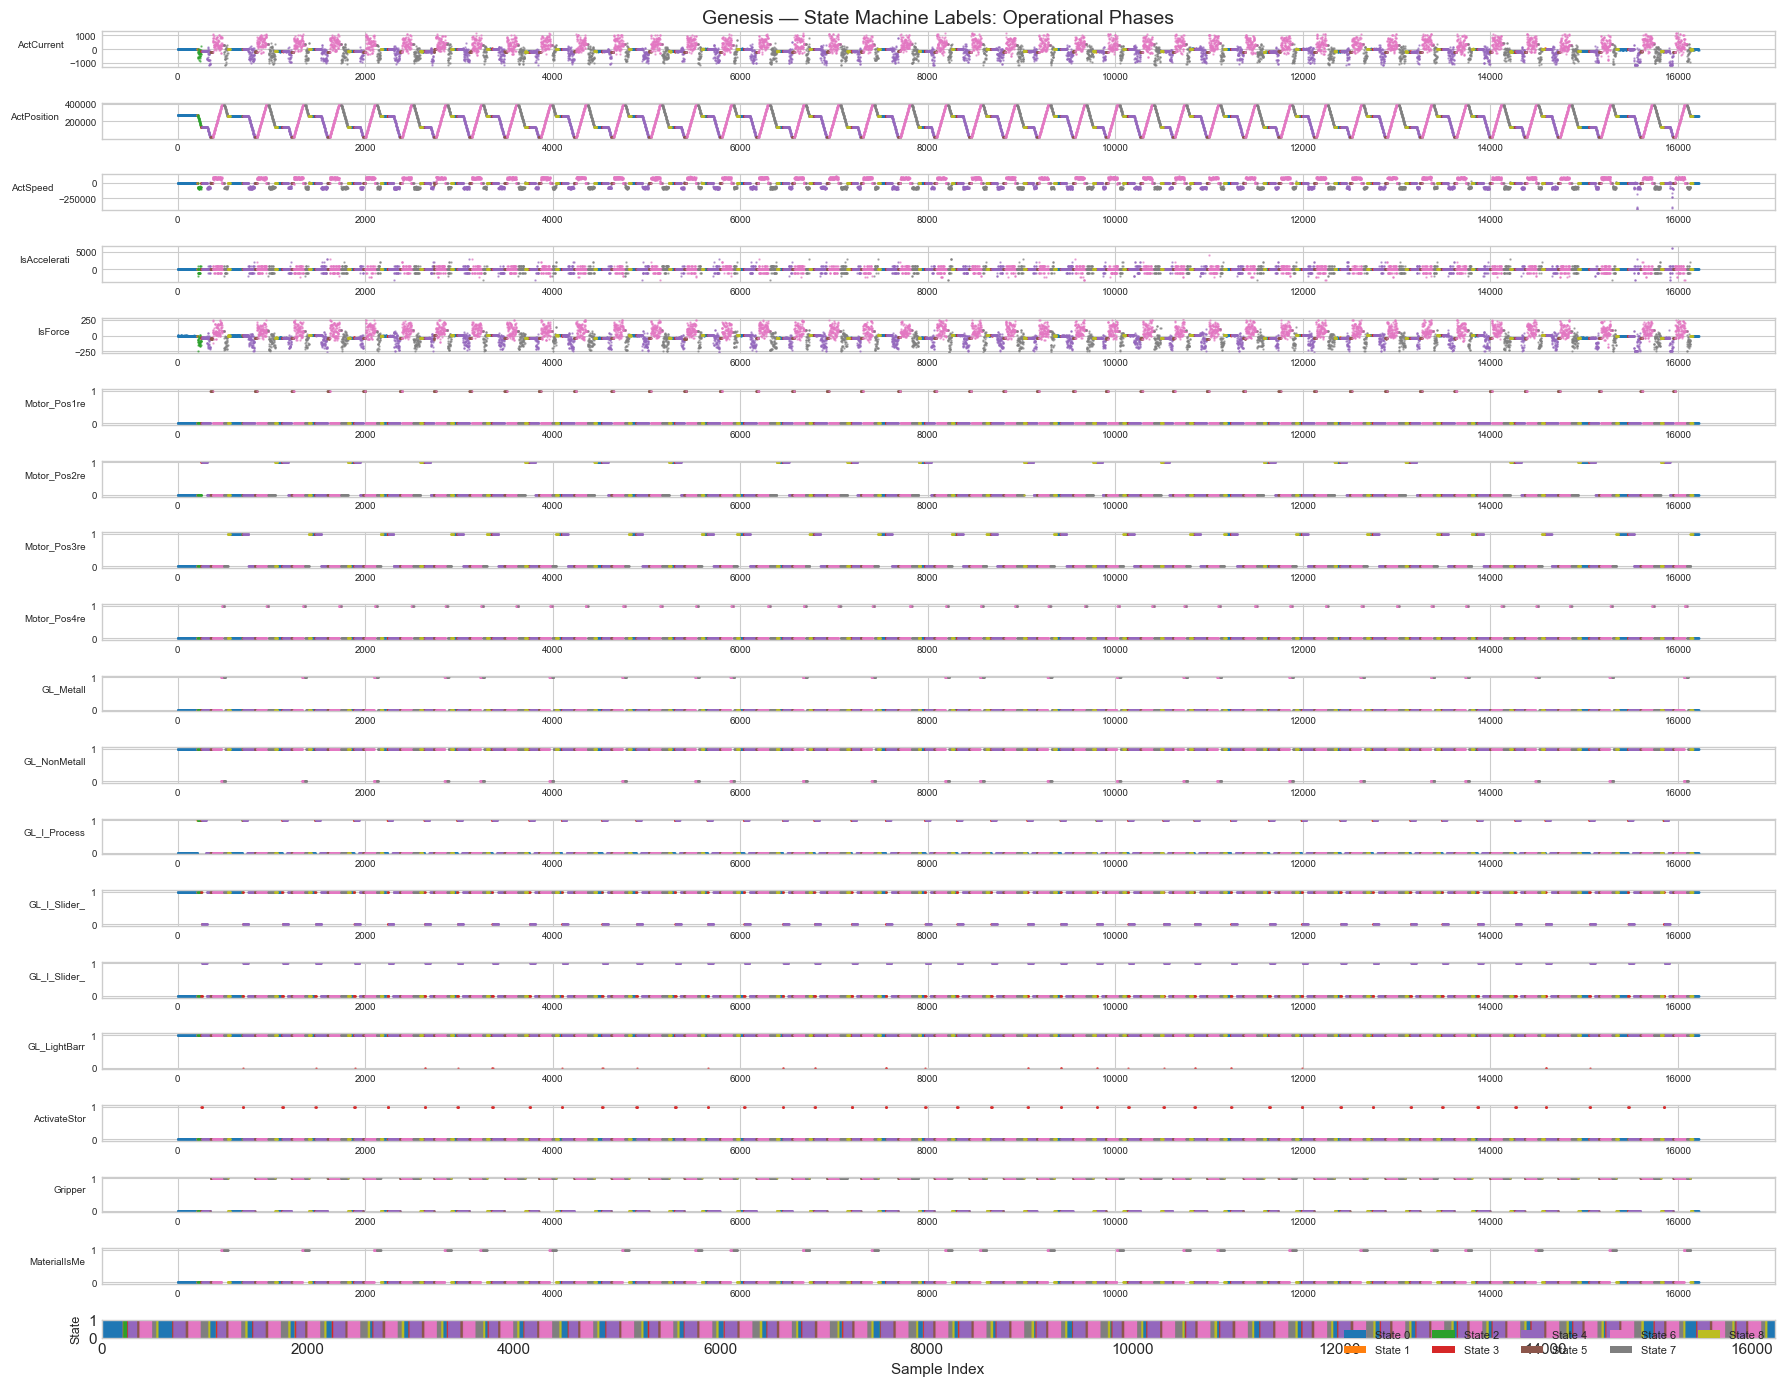

Number of unique operational states: 9
State distribution:
Label
0    1882
1      55
2      76
3     383
4    4518
5     942
6    5193
7    2229
8     942
Name: count, dtype: int64


In [4]:
# Visualize state machine labels
sensor_cols_state = [c for c in state_labels.columns if c not in ['Timestamp', 'Label']]

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(len(sensor_cols_state) + 1, 1, height_ratios=[1] * len(sensor_cols_state) + [0.5])

# Color map for states
unique_states = sorted(state_labels['Label'].unique())
n_states = len(unique_states)
state_colors = plt.cm.tab10(np.linspace(0, 1, max(n_states, 10)))
state_color_map = {s: state_colors[i] for i, s in enumerate(unique_states)}

# Plot each sensor with state coloring
for i, col in enumerate(sensor_cols_state):
    ax = fig.add_subplot(gs[i])
    for state in unique_states:
        mask = state_labels['Label'] == state
        indices = np.where(mask)[0]
        if len(indices) > 0:
            ax.scatter(indices, state_labels.loc[mask, col].values, 
                      c=[state_color_map[state]], s=0.5, alpha=0.6)
    ax.set_ylabel(col.split('.')[-1][:12], fontsize=7, rotation=0, ha='right')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.set_title('Genesis — State Machine Labels: Operational Phases', fontsize=14)

# Plot state labels as colored bar
ax_label = fig.add_subplot(gs[-1])
for j in range(len(state_labels)):
    ax_label.axvspan(j, j+1, color=state_color_map[state_labels['Label'].iloc[j]], alpha=0.8)
ax_label.set_ylabel('State', fontsize=9)
ax_label.set_xlabel('Sample Index')
ax_label.set_xlim(0, len(state_labels))

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=state_color_map[s], label=f'State {s}') for s in unique_states]
ax_label.legend(handles=legend_elements, loc='upper right', ncol=min(n_states, 5), fontsize=8)

plt.tight_layout()
plt.show()
print(f"Number of unique operational states: {n_states}")
print(f"State distribution:")
print(state_labels['Label'].value_counts().sort_index())


## 3. Anomaly Labels — Fault Detection Ground Truth

The anomaly labels file contains data with injected faults. The `Label` column indicates normal (0) vs anomalous (non-zero) operation. This provides ground truth for **unsupervised anomaly detection** evaluation.


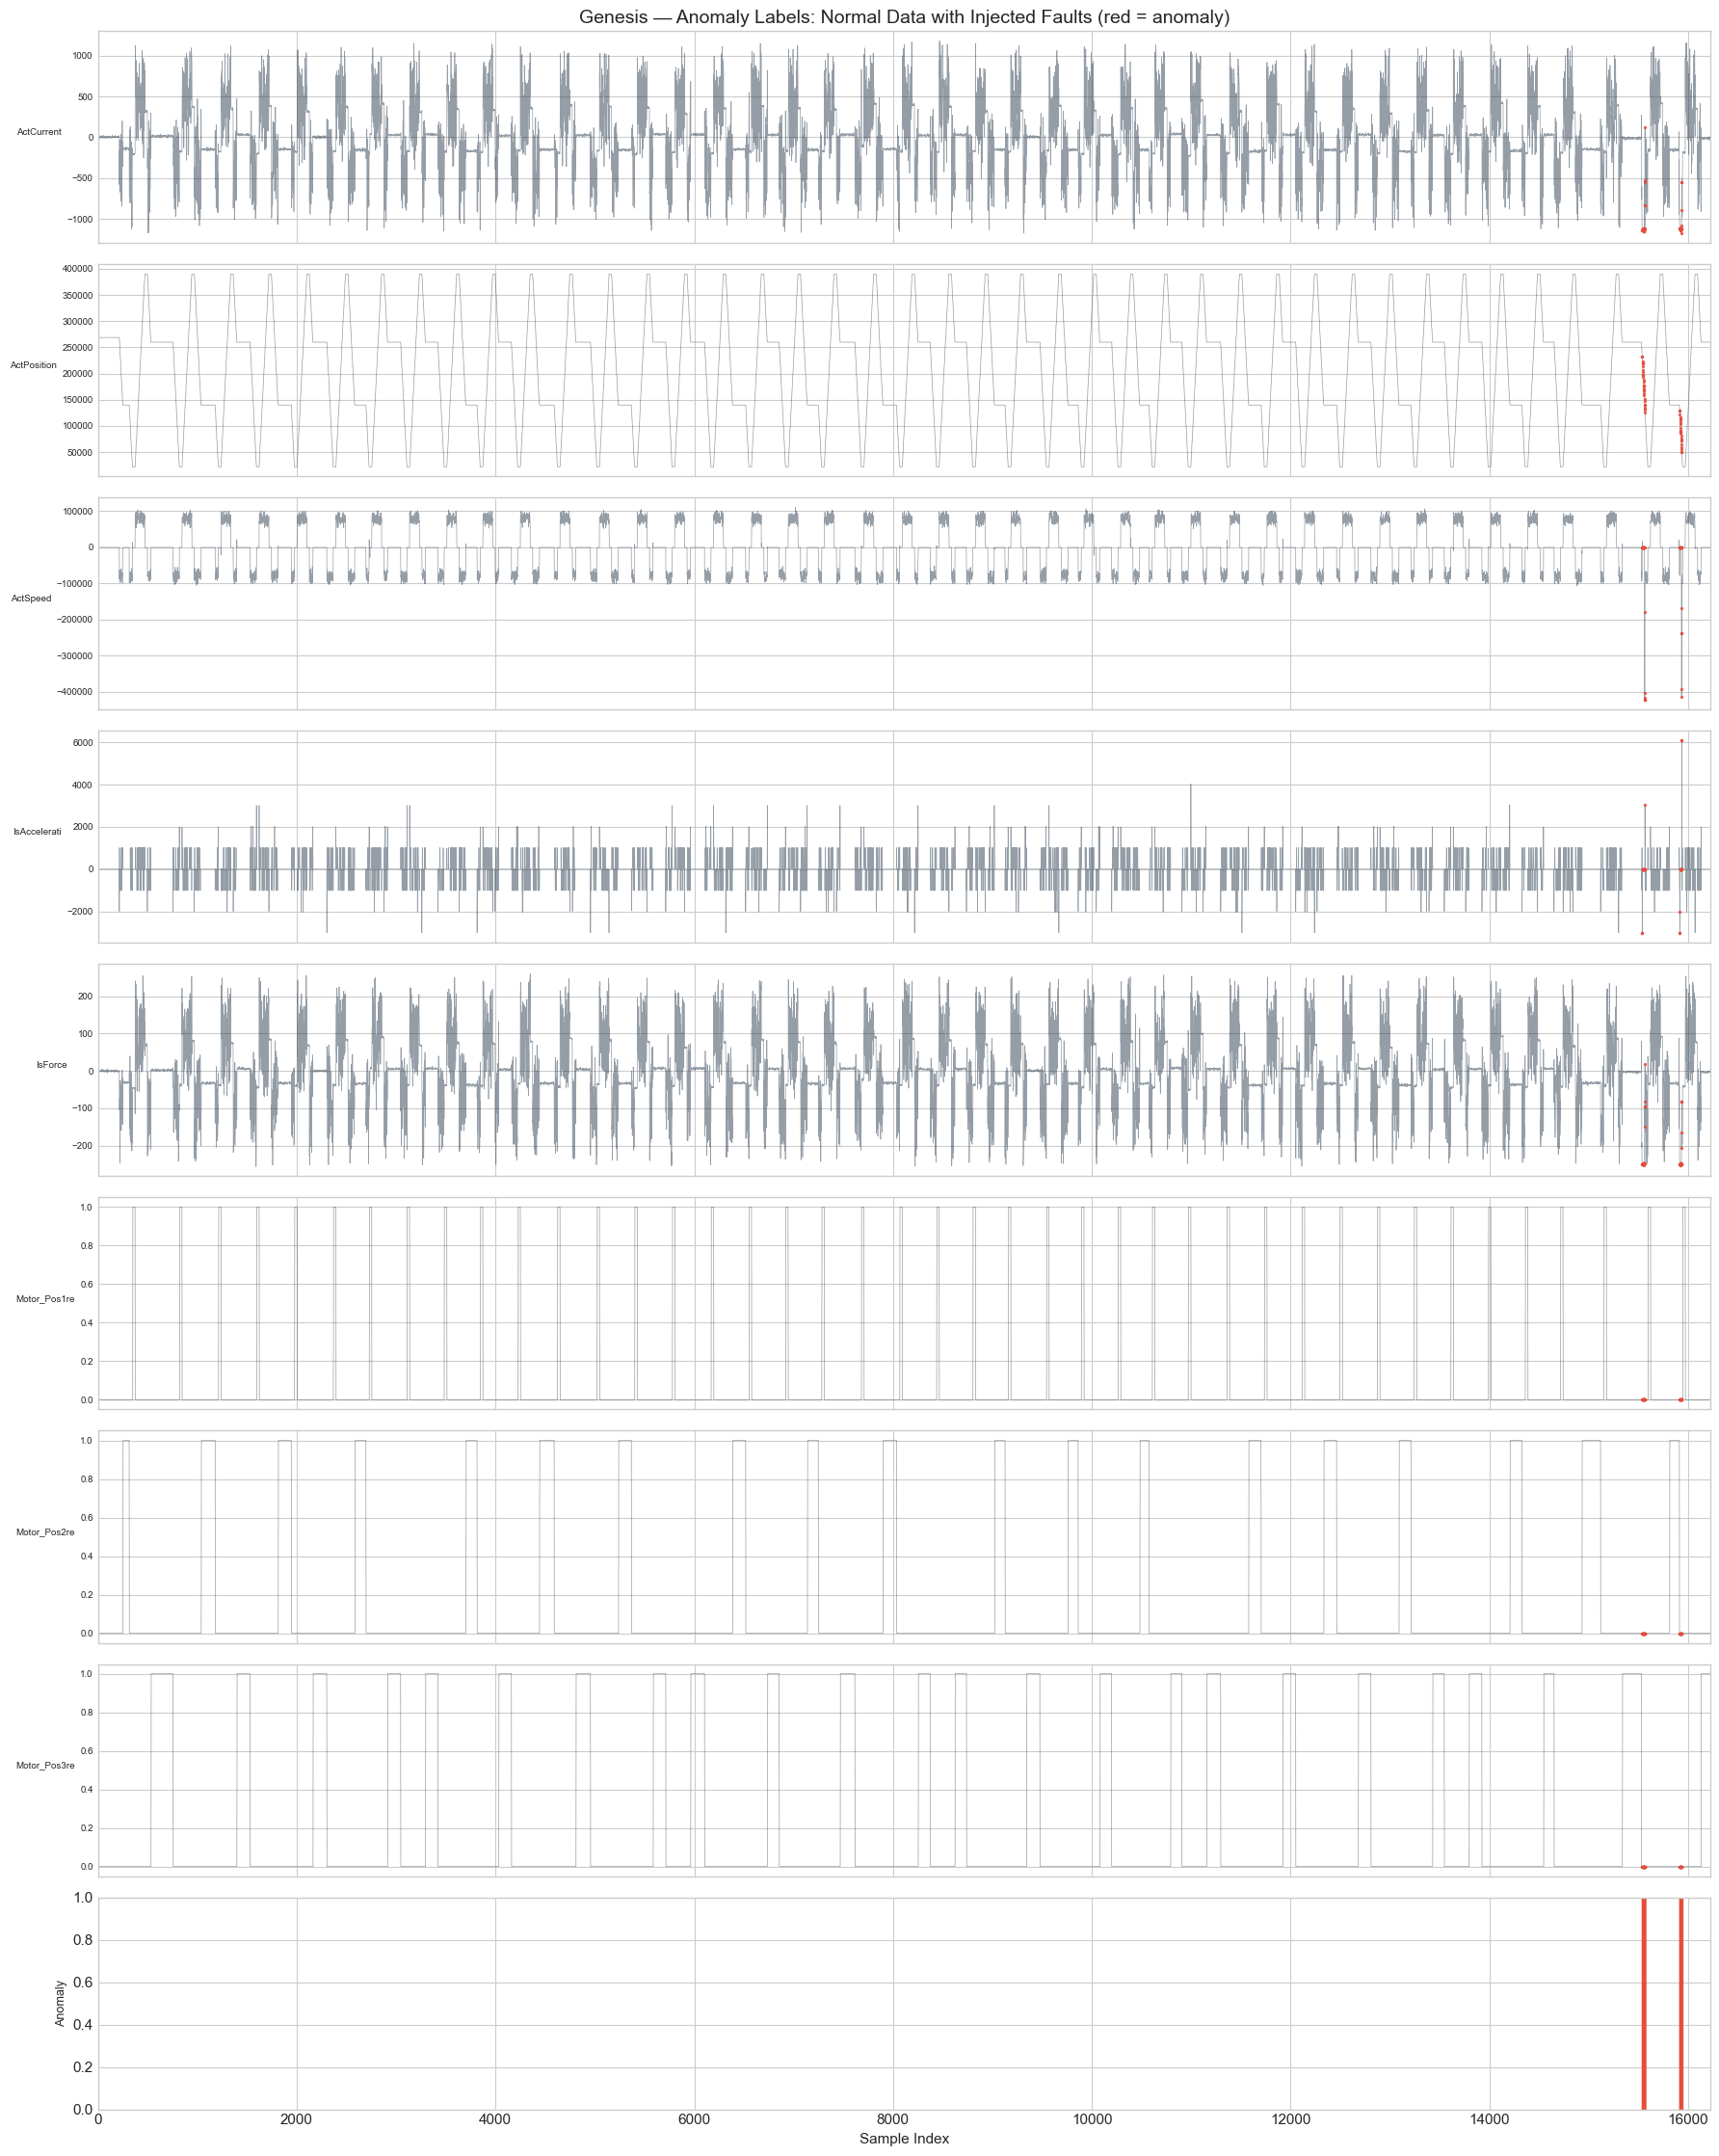

Total samples: 16220
Anomaly samples: 50 (0.3%)
Anomaly label values: [np.int64(0), np.int64(1), np.int64(2)]


In [5]:
# Visualize anomaly labels data
sensor_cols_anom = [c for c in anomaly_labels.columns if c not in ['Timestamp', 'Label']]

fig, axes = plt.subplots(min(8, len(sensor_cols_anom)) + 1, 1, 
                          figsize=(18, 2.5 * (min(8, len(sensor_cols_anom)) + 1)), sharex=True)

selected_sensors = sensor_cols_anom[:8]

for i, col in enumerate(selected_sensors):
    ax = axes[i]
    # Normal points
    normal_mask = anomaly_labels['Label'] == 0
    anomaly_mask = anomaly_labels['Label'] != 0
    
    ax.plot(range(len(anomaly_labels)), anomaly_labels[col].values, linewidth=0.5, color='#2c3e50', alpha=0.5)
    ax.scatter(np.where(anomaly_mask)[0], anomaly_labels.loc[anomaly_mask, col].values, 
              c='#e74c3c', s=2, alpha=0.8, zorder=5)
    ax.set_ylabel(col.split('.')[-1][:12], fontsize=7, rotation=0, ha='right')
    ax.tick_params(labelsize=7)

# Label bar
ax_label = axes[-1]
for j in range(len(anomaly_labels)):
    if anomaly_labels['Label'].iloc[j] != 0:
        ax_label.axvspan(j, j+1, color='#e74c3c', alpha=0.8)
ax_label.set_ylabel('Anomaly', fontsize=9)
ax_label.set_xlabel('Sample Index')
ax_label.set_xlim(0, len(anomaly_labels))

axes[0].set_title('Genesis — Anomaly Labels: Normal Data with Injected Faults (red = anomaly)', fontsize=14)
plt.tight_layout()
plt.show()

anomaly_ratio = (anomaly_labels['Label'] != 0).mean() * 100
print(f"Total samples: {len(anomaly_labels)}")
print(f"Anomaly samples: {(anomaly_labels['Label'] != 0).sum()} ({anomaly_ratio:.1f}%)")
print(f"Anomaly label values: {sorted(anomaly_labels['Label'].unique())}")


## 4. Linear Drive Anomalies — Mechanical Fault Patterns

The linear drive dataset captures anomalies related to the **mechanical actuator** of the system. These represent realistic degradation patterns relevant to **predictive maintenance**.


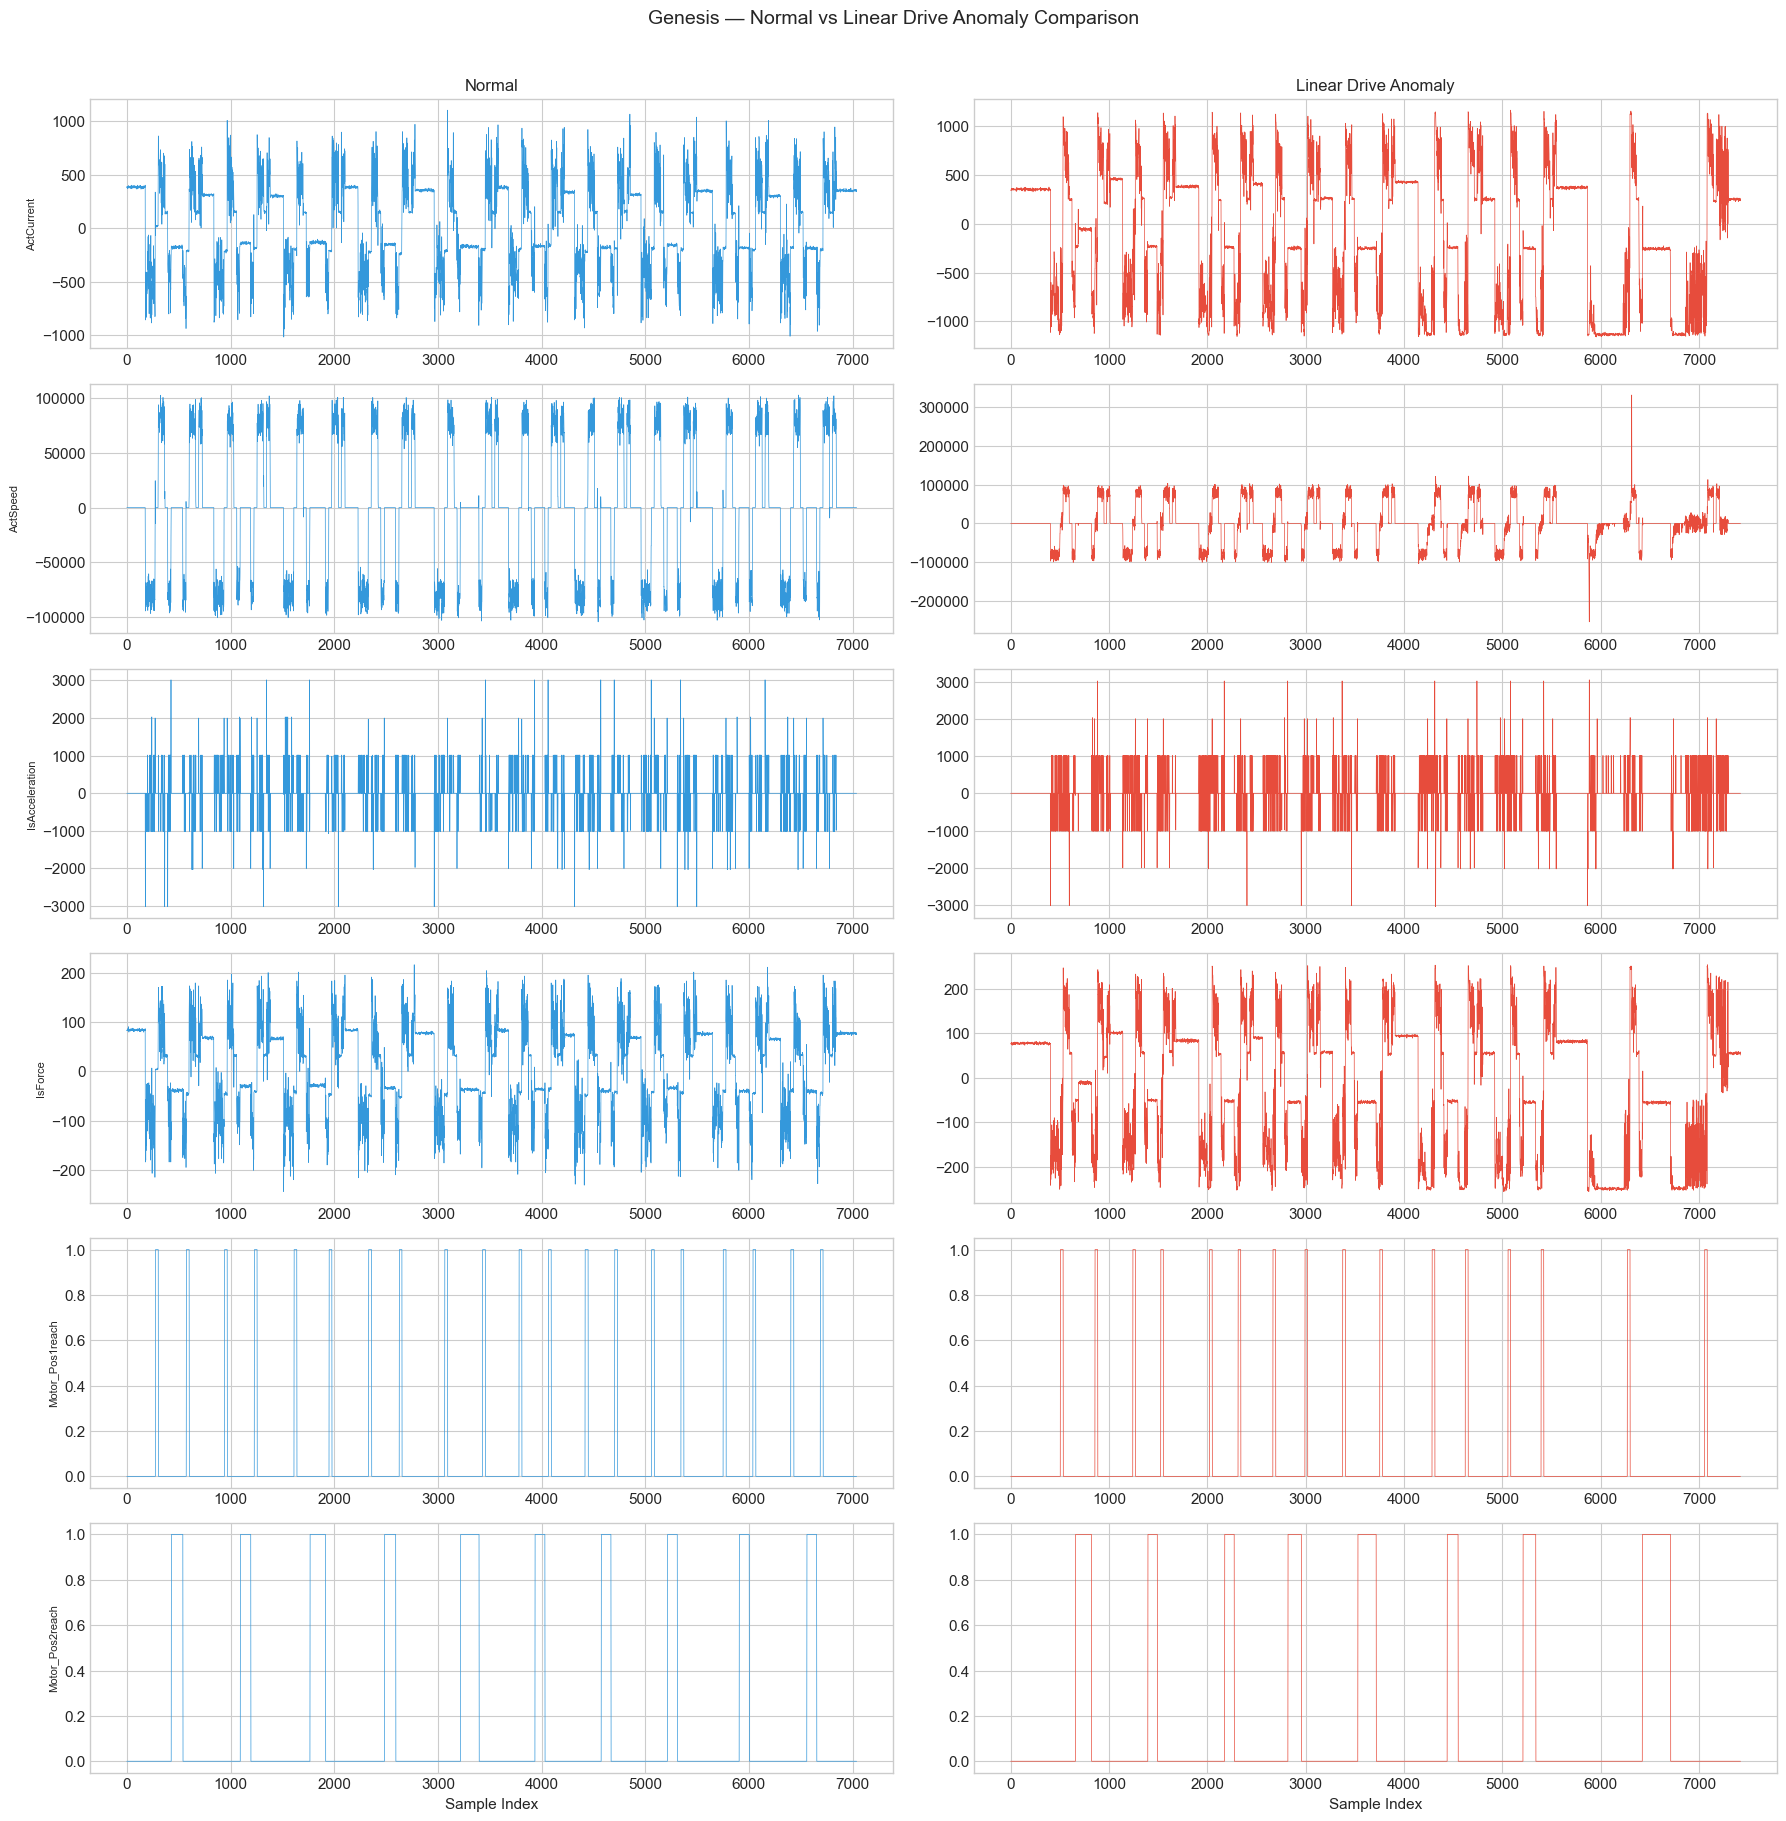

Key Insight: Linear drive anomalies show altered motor behavior patterns.
These represent realistic mechanical degradation for predictive maintenance research.


In [6]:
# Compare normal vs linear drive anomaly data
sensor_cols_ld = [c for c in lineardrive.columns if c != 'Timestamp']

# Select key motor-related features
motor_features = [c for c in sensor_cols_ld if 'Motor' in c or 'Act' in c][:6]
if len(motor_features) < 4:
    motor_features = sensor_cols_ld[:6]

fig, axes = plt.subplots(len(motor_features), 2, figsize=(18, 3 * len(motor_features)))

# Match features between normal and lineardrive
normal_sensor_cols = [c for c in normal.columns if c != 'Timestamp']

for i, feat in enumerate(motor_features):
    # Normal data
    if feat in normal.columns:
        axes[i][0].plot(normal[feat].values[:len(lineardrive)], linewidth=0.5, color='#3498db')
        axes[i][0].set_ylabel(feat.split('.')[-1][:15], fontsize=8)
    axes[i][0].set_title('Normal' if i == 0 else '', fontsize=12)
    
    # Linear drive anomaly data
    axes[i][1].plot(lineardrive[feat].values, linewidth=0.5, color='#e74c3c')
    axes[i][1].set_title('Linear Drive Anomaly' if i == 0 else '', fontsize=12)

axes[-1][0].set_xlabel('Sample Index')
axes[-1][1].set_xlabel('Sample Index')
plt.suptitle('Genesis — Normal vs Linear Drive Anomaly Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Key Insight: Linear drive anomalies show altered motor behavior patterns.")
print("These represent realistic mechanical degradation for predictive maintenance research.")


## 5. Pressure Anomalies — Process Fault Patterns

The pressure dataset captures anomalies related to the **pneumatic system** (gripper pressure). These represent a different fault mode compared to linear drive anomalies.


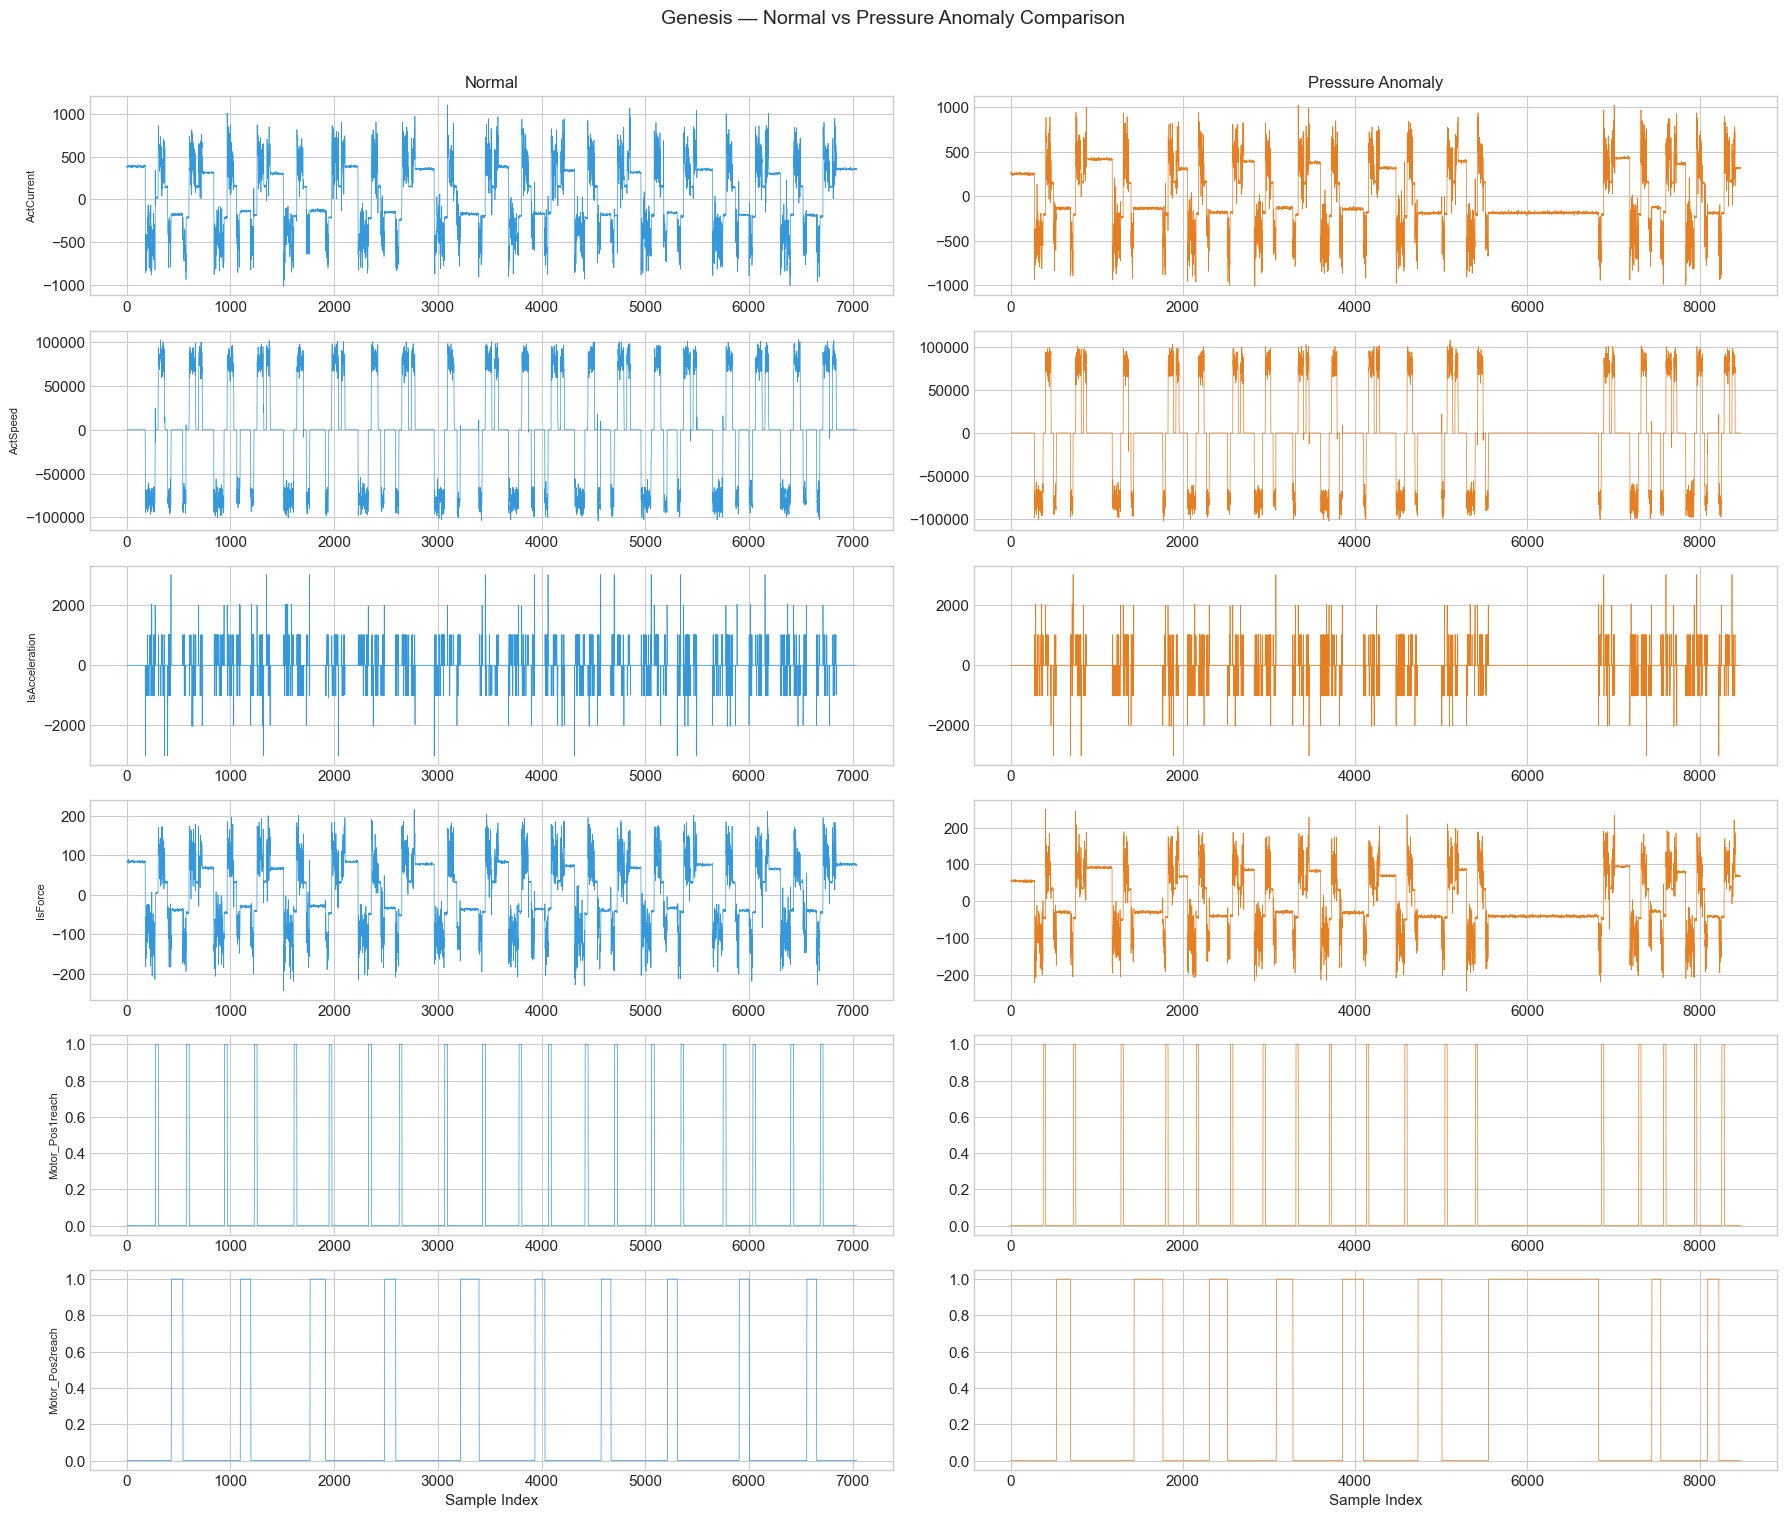

Key Insight: Pressure anomalies affect different features than linear drive anomalies.
Having multiple fault types enables multi-class anomaly detection research.


In [7]:
# Compare normal vs pressure anomaly data
sensor_cols_pr = [c for c in pressure.columns if c != 'Timestamp']

fig, axes = plt.subplots(min(6, len(sensor_cols_pr)), 2, figsize=(18, 15))
selected = sensor_cols_pr[:6]

for i, feat in enumerate(selected):
    # Normal
    if feat in normal.columns:
        axes[i][0].plot(normal[feat].values[:len(pressure)], linewidth=0.5, color='#3498db')
    axes[i][0].set_ylabel(feat.split('.')[-1][:15], fontsize=8)
    axes[i][0].set_title('Normal' if i == 0 else '', fontsize=12)
    
    # Pressure anomaly
    axes[i][1].plot(pressure[feat].values, linewidth=0.5, color='#e67e22')
    axes[i][1].set_title('Pressure Anomaly' if i == 0 else '', fontsize=12)

axes[-1][0].set_xlabel('Sample Index')
axes[-1][1].set_xlabel('Sample Index')
plt.suptitle('Genesis — Normal vs Pressure Anomaly Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Key Insight: Pressure anomalies affect different features than linear drive anomalies.")
print("Having multiple fault types enables multi-class anomaly detection research.")


## 6. Feature Correlation Structure — Normal vs Anomalous

Understanding how feature correlations change during anomalies is key for reconstruction-based anomaly detection methods.


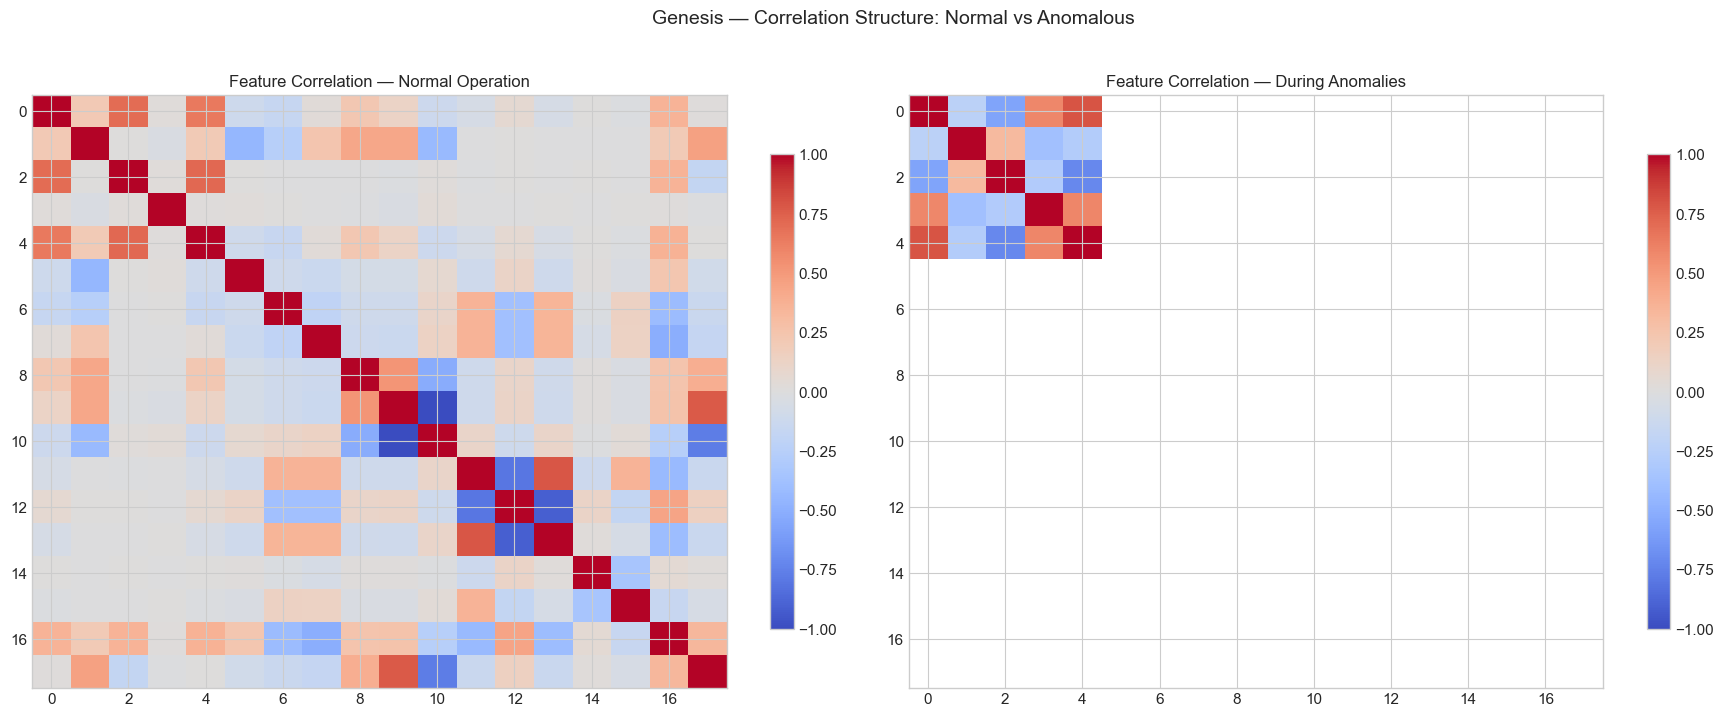

Key Insight: Anomalies disrupt the normal correlation structure.
Reconstruction-based methods (autoencoders, VAEs) can detect these disruptions.


In [8]:
# Correlation comparison
sensor_cols_anom = [c for c in anomaly_labels.columns if c not in ['Timestamp', 'Label']]
normal_data = anomaly_labels[anomaly_labels['Label'] == 0][sensor_cols_anom]
anomaly_data = anomaly_labels[anomaly_labels['Label'] != 0][sensor_cols_anom]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

if len(normal_data) > 10:
    corr_normal = normal_data.corr()
    im1 = axes[0].imshow(corr_normal.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_title('Feature Correlation — Normal Operation', fontsize=12)
    plt.colorbar(im1, ax=axes[0], shrink=0.8)

if len(anomaly_data) > 10:
    corr_anomaly = anomaly_data.corr()
    im2 = axes[1].imshow(corr_anomaly.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[1].set_title('Feature Correlation — During Anomalies', fontsize=12)
    plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle('Genesis — Correlation Structure: Normal vs Anomalous', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("Key Insight: Anomalies disrupt the normal correlation structure.")
print("Reconstruction-based methods (autoencoders, VAEs) can detect these disruptions.")


## Summary: How Genesis Supports Your Research

### Unsupervised Anomaly Detection
- **Multiple fault types**: Linear drive anomalies, pressure anomalies, and labeled anomalies
- **Clear ground truth** with binary anomaly labels for evaluation
- **Physical sensor data** — not synthetic, capturing real-world noise and dynamics

### MTS Clustering
- **State machine labels** define distinct operational phases (pick, move, place, sort)
- Perfect ground truth for evaluating TICC-style temporal clustering
- Each operational phase has a distinct multivariate signature

### Predictive Maintenance / Early Detection
- **Mechanical degradation** patterns in linear drive data
- **Pneumatic system faults** in pressure data
- Multiple fault modes enable multi-class fault diagnosis research

### Complexity Assessment
- **Moderate complexity**: 18 dimensions, ~16K samples per file
- **Clear structure**: Well-defined operational cycles make it accessible yet challenging
- **Industry 5.0 alignment**: Smart manufacturing demonstrator with human-robot interaction
- **Under-explored**: Less saturated than SMD or SWaT, offering research opportunities


## 7. Operational Phase Clustering (State Machine Deep Dive)

Genesis is **uniquely suited for clustering research** because the state machine labels provide **GROUND TRUTH for temporal segmentation**. The 9 operational states (0-8) correspond to distinct phases of the pick-and-place cycle (e.g., idle, moving to pick position, gripping, transporting, releasing, returning). TICC or similar temporal clustering methods should recover these 9 operational phases from the raw sensor data alone.

**Note:** Anomalies can occur **WITHIN** any phase — clusters are operational regimes, not anomaly types.

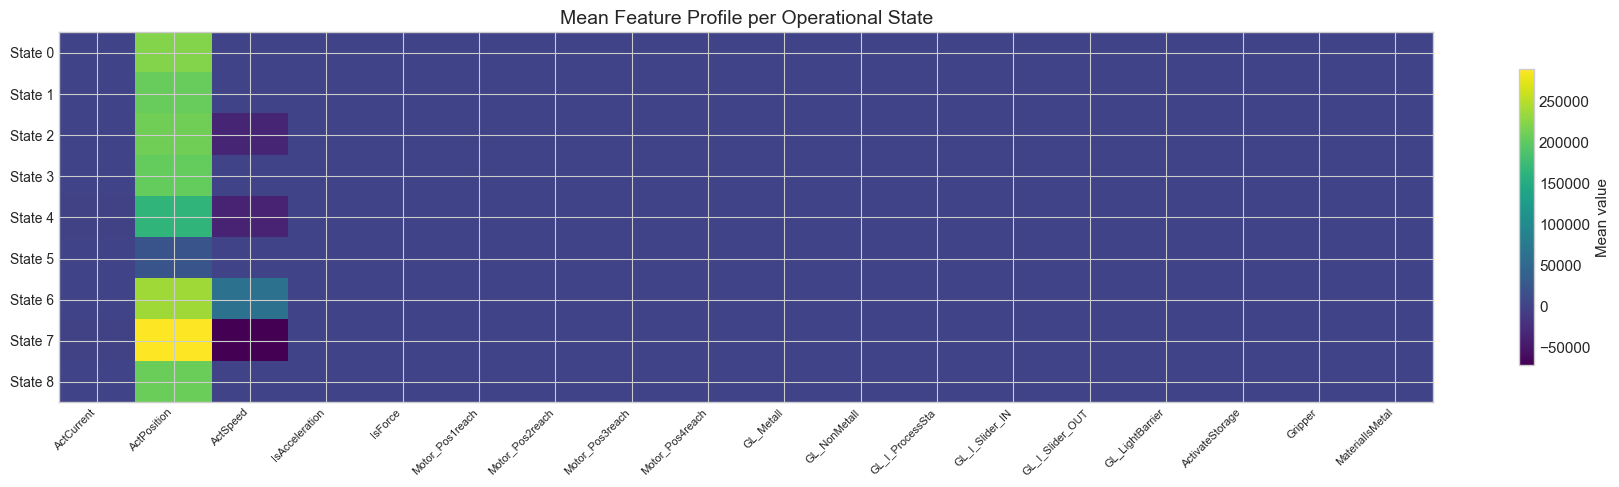

Each row is a state's mean feature signature. Distinct rows = distinct operational regimes.
States with similar profiles may be harder to separate via clustering.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import svd

# --- 7a: Mean feature profile per state (heatmap) ---
sensor_cols_sl = [c for c in state_labels.columns if c not in ['Timestamp', 'Label']]

# Compute mean feature value per state
state_means = state_labels.groupby('Label')[sensor_cols_sl].mean()

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(state_means.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(len(state_means)))
ax.set_yticklabels([f'State {s}' for s in state_means.index], fontsize=10)
ax.set_xticks(range(len(sensor_cols_sl)))
ax.set_xticklabels([c.split('.')[-1][:15] for c in sensor_cols_sl], rotation=45, ha='right', fontsize=8)
ax.set_title('Mean Feature Profile per Operational State', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.8, label='Mean value')
plt.tight_layout()
plt.show()

print("Each row is a state's mean feature signature. Distinct rows = distinct operational regimes.")
print("States with similar profiles may be harder to separate via clustering.")


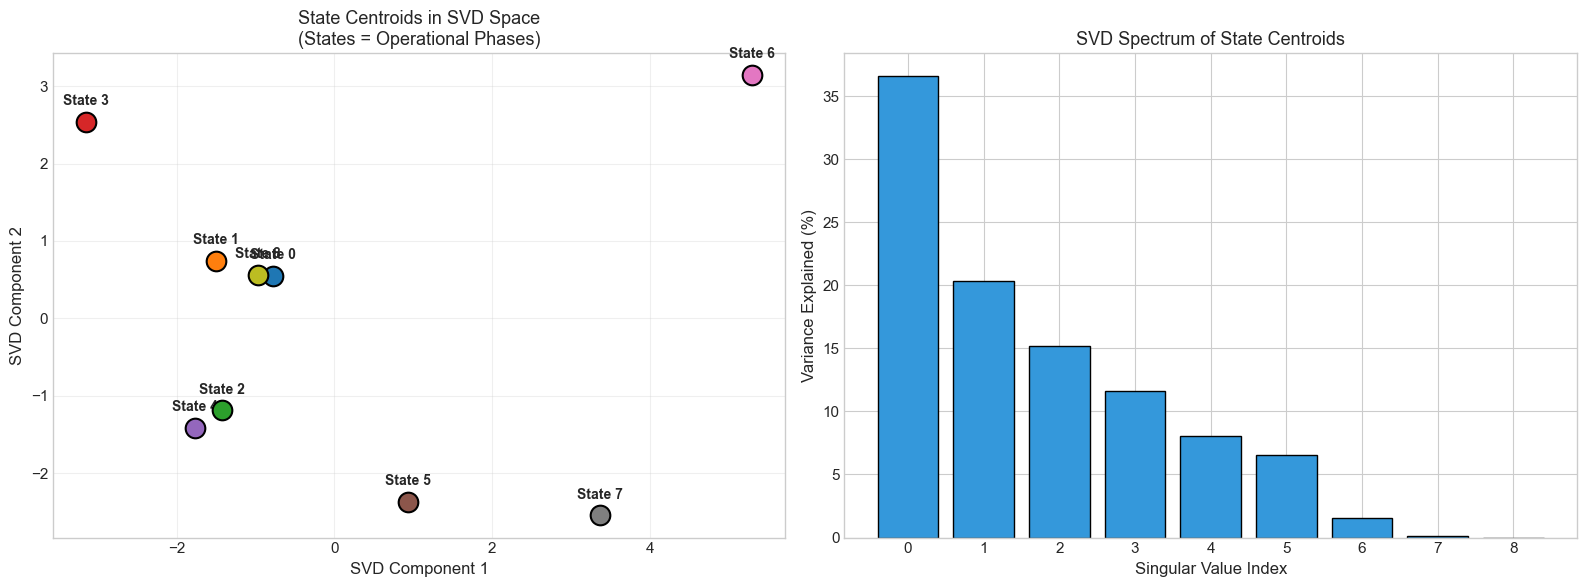

Top-2 SVD components explain 36.6% + 20.4% = 57.0% of variance.
Well-separated clusters in SVD space suggest TICC can recover these phases from raw data.


In [10]:
# --- 7b: SVD projection of state-wise feature means ---
# Standardize before SVD
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
state_means_scaled = scaler.fit_transform(state_means.values)

U, s, Vt = svd(state_means_scaled, full_matrices=False)
projected = U[:, :2] * s[:2]  # project onto first 2 singular vectors

unique_states = sorted(state_labels['Label'].unique())
state_colors_map = plt.cm.tab10(np.linspace(0, 1, max(len(unique_states), 10)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: SVD scatter
ax = axes[0]
for i, state in enumerate(state_means.index):
    ax.scatter(projected[i, 0], projected[i, 1], c=[state_colors_map[state]], 
               s=200, edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(f'State {state}', (projected[i, 0], projected[i, 1]),
               fontsize=10, ha='center', va='bottom', 
               xytext=(0, 10), textcoords='offset points', fontweight='bold')
ax.set_xlabel('SVD Component 1', fontsize=12)
ax.set_ylabel('SVD Component 2', fontsize=12)
ax.set_title('State Centroids in SVD Space\n(States = Operational Phases)', fontsize=13)
ax.grid(True, alpha=0.3)

# Right: explained variance
explained_var = (s ** 2) / np.sum(s ** 2) * 100
ax2 = axes[1]
ax2.bar(range(len(s)), explained_var, color='#3498db', edgecolor='black')
ax2.set_xlabel('Singular Value Index', fontsize=12)
ax2.set_ylabel('Variance Explained (%)', fontsize=12)
ax2.set_title('SVD Spectrum of State Centroids', fontsize=13)
ax2.set_xticks(range(len(s)))

plt.tight_layout()
plt.show()

print(f"Top-2 SVD components explain {explained_var[0]:.1f}% + {explained_var[1]:.1f}% = {sum(explained_var[:2]):.1f}% of variance.")
print("Well-separated clusters in SVD space suggest TICC can recover these phases from raw data.")


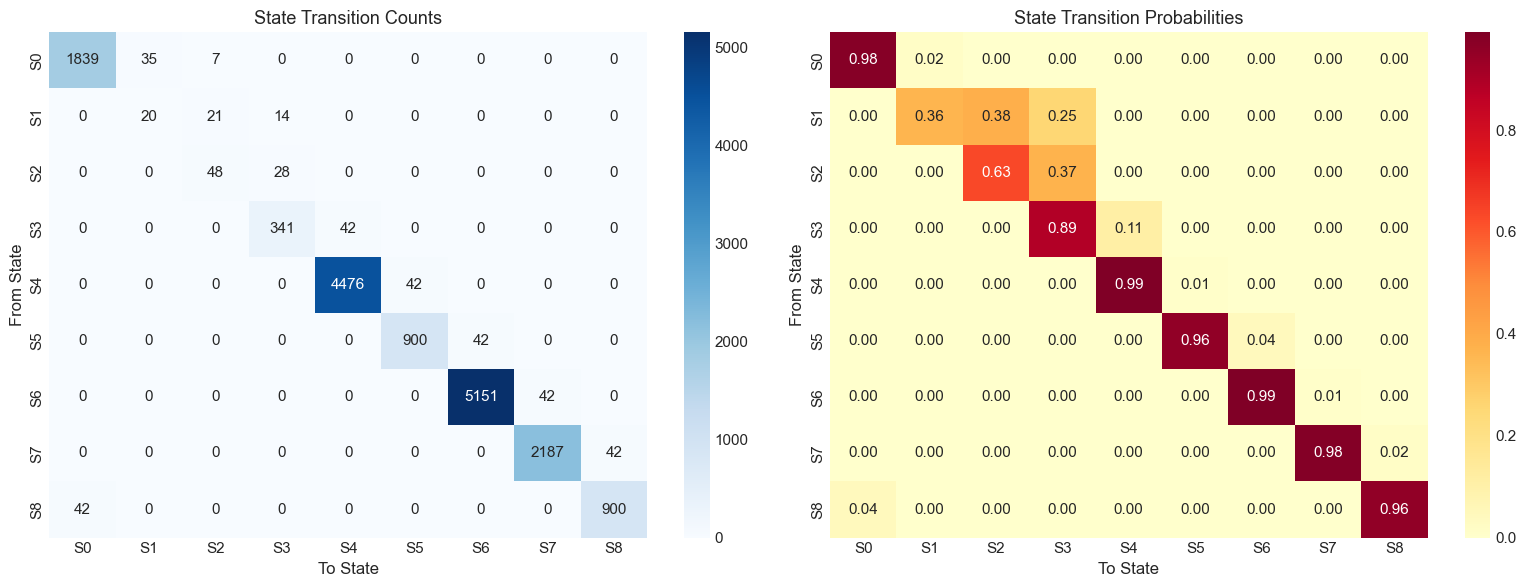

Dominant transitions (probability > 0.1, excluding self-loops):
  State 1 -> State 2: 0.38
  State 1 -> State 3: 0.25
  State 2 -> State 3: 0.37
  State 3 -> State 4: 0.11

The transition matrix reveals the cyclic structure of the pick-and-place process.
High self-transition probabilities on the diagonal indicate states persist over multiple timesteps.


In [11]:
# --- 7c: State transition matrix ---
labels_seq = state_labels['Label'].values

# Count transitions
n_states = len(unique_states)
transition_counts = np.zeros((n_states, n_states), dtype=int)
for i in range(len(labels_seq) - 1):
    transition_counts[labels_seq[i], labels_seq[i+1]] += 1

# Normalize to probabilities (row-wise)
row_sums = transition_counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
transition_probs = transition_counts / row_sums

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(transition_counts, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'S{s}' for s in unique_states],
            yticklabels=[f'S{s}' for s in unique_states], ax=axes[0])
axes[0].set_xlabel('To State', fontsize=12)
axes[0].set_ylabel('From State', fontsize=12)
axes[0].set_title('State Transition Counts', fontsize=13)

# Transition probabilities
sns.heatmap(transition_probs, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'S{s}' for s in unique_states],
            yticklabels=[f'S{s}' for s in unique_states], ax=axes[1])
axes[1].set_xlabel('To State', fontsize=12)
axes[1].set_ylabel('From State', fontsize=12)
axes[1].set_title('State Transition Probabilities', fontsize=13)

plt.tight_layout()
plt.show()

# Identify the dominant cycle
print("Dominant transitions (probability > 0.1, excluding self-loops):")
for i in range(n_states):
    for j in range(n_states):
        if i != j and transition_probs[i, j] > 0.1:
            print(f"  State {i} -> State {j}: {transition_probs[i, j]:.2f}")

print("\nThe transition matrix reveals the cyclic structure of the pick-and-place process.")
print("High self-transition probabilities on the diagonal indicate states persist over multiple timesteps.")


## 8. Anomalies Within Operational Phases

This section demonstrates the **key distinction**: clusters (operational phases) are **NOT** anomaly types. Anomalies are deviations that can occur **within any operational phase**. By cross-tabulating anomaly labels with state machine labels, we can see which phases are more susceptible to faults and how anomalous behavior manifests within a given phase.

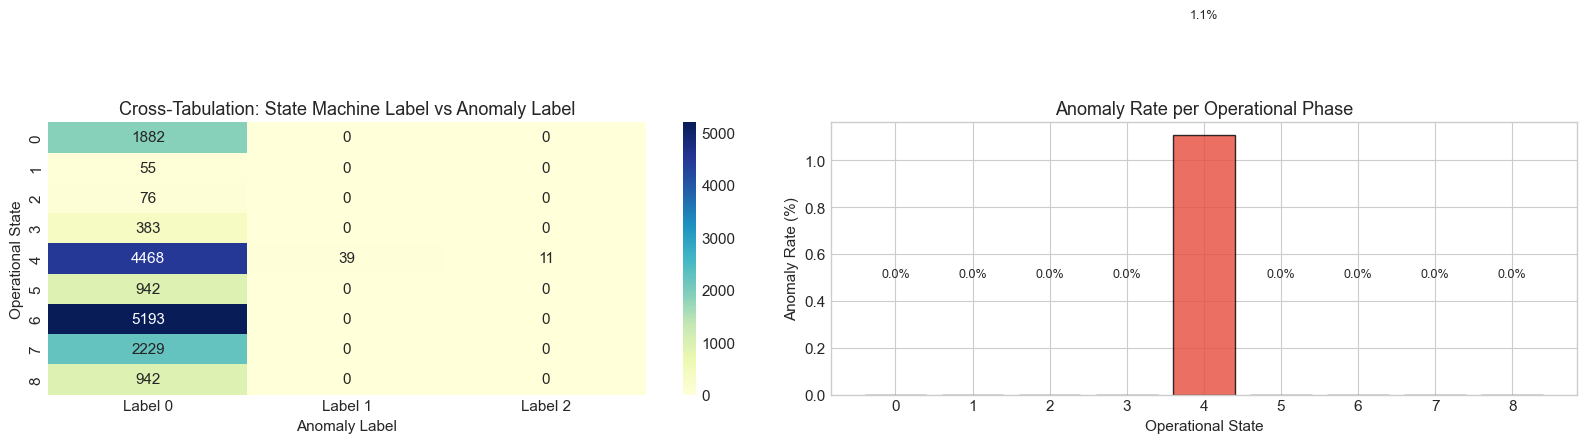

Cross-tabulation shows anomalies are NOT uniformly distributed across phases.

Anomaly rates by state:
  State 0: 0.0%
  State 1: 0.0%
  State 2: 0.0%
  State 3: 0.0%
  State 4: 1.1% <-- highest
  State 5: 0.0%
  State 6: 0.0%
  State 7: 0.0%
  State 8: 0.0%


In [12]:
# --- 8a: Cross-tabulate anomaly labels vs state machine labels ---
# Both anomaly_labels and state_labels have the same number of rows (16220)
assert len(anomaly_labels) == len(state_labels), "Mismatch in row counts"

cross_tab = pd.crosstab(state_labels['Label'], anomaly_labels['Label'],
                         rownames=['State'], colnames=['Anomaly Label'])
cross_tab.columns = [f'Label {c}' for c in cross_tab.columns]

# Compute anomaly rate per state
anomaly_rate_per_state = (anomaly_labels['Label'].values != 0).astype(int)
state_anomaly_rate = pd.DataFrame({
    'State': state_labels['Label'].values,
    'IsAnomaly': anomaly_rate_per_state
}).groupby('State')['IsAnomaly'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cross-tabulation heatmap
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Cross-Tabulation: State Machine Label vs Anomaly Label', fontsize=13)
axes[0].set_ylabel('Operational State', fontsize=11)
axes[0].set_xlabel('Anomaly Label', fontsize=11)

# Anomaly rate per state
bars = axes[1].bar(state_anomaly_rate.index, state_anomaly_rate.values, 
                    color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Operational State', fontsize=11)
axes[1].set_ylabel('Anomaly Rate (%)', fontsize=11)
axes[1].set_title('Anomaly Rate per Operational Phase', fontsize=13)
axes[1].set_xticks(range(n_states))
for bar, val in zip(bars, state_anomaly_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Cross-tabulation shows anomalies are NOT uniformly distributed across phases.")
print(f"\nAnomaly rates by state:")
for state, rate in state_anomaly_rate.items():
    marker = " <-- highest" if rate == state_anomaly_rate.max() else ""
    print(f"  State {state}: {rate:.1f}%{marker}")


Visualizing State 4 (highest anomaly rate: 1.1%)
  Normal samples in this state: 4468
  Anomalous samples in this state: 50


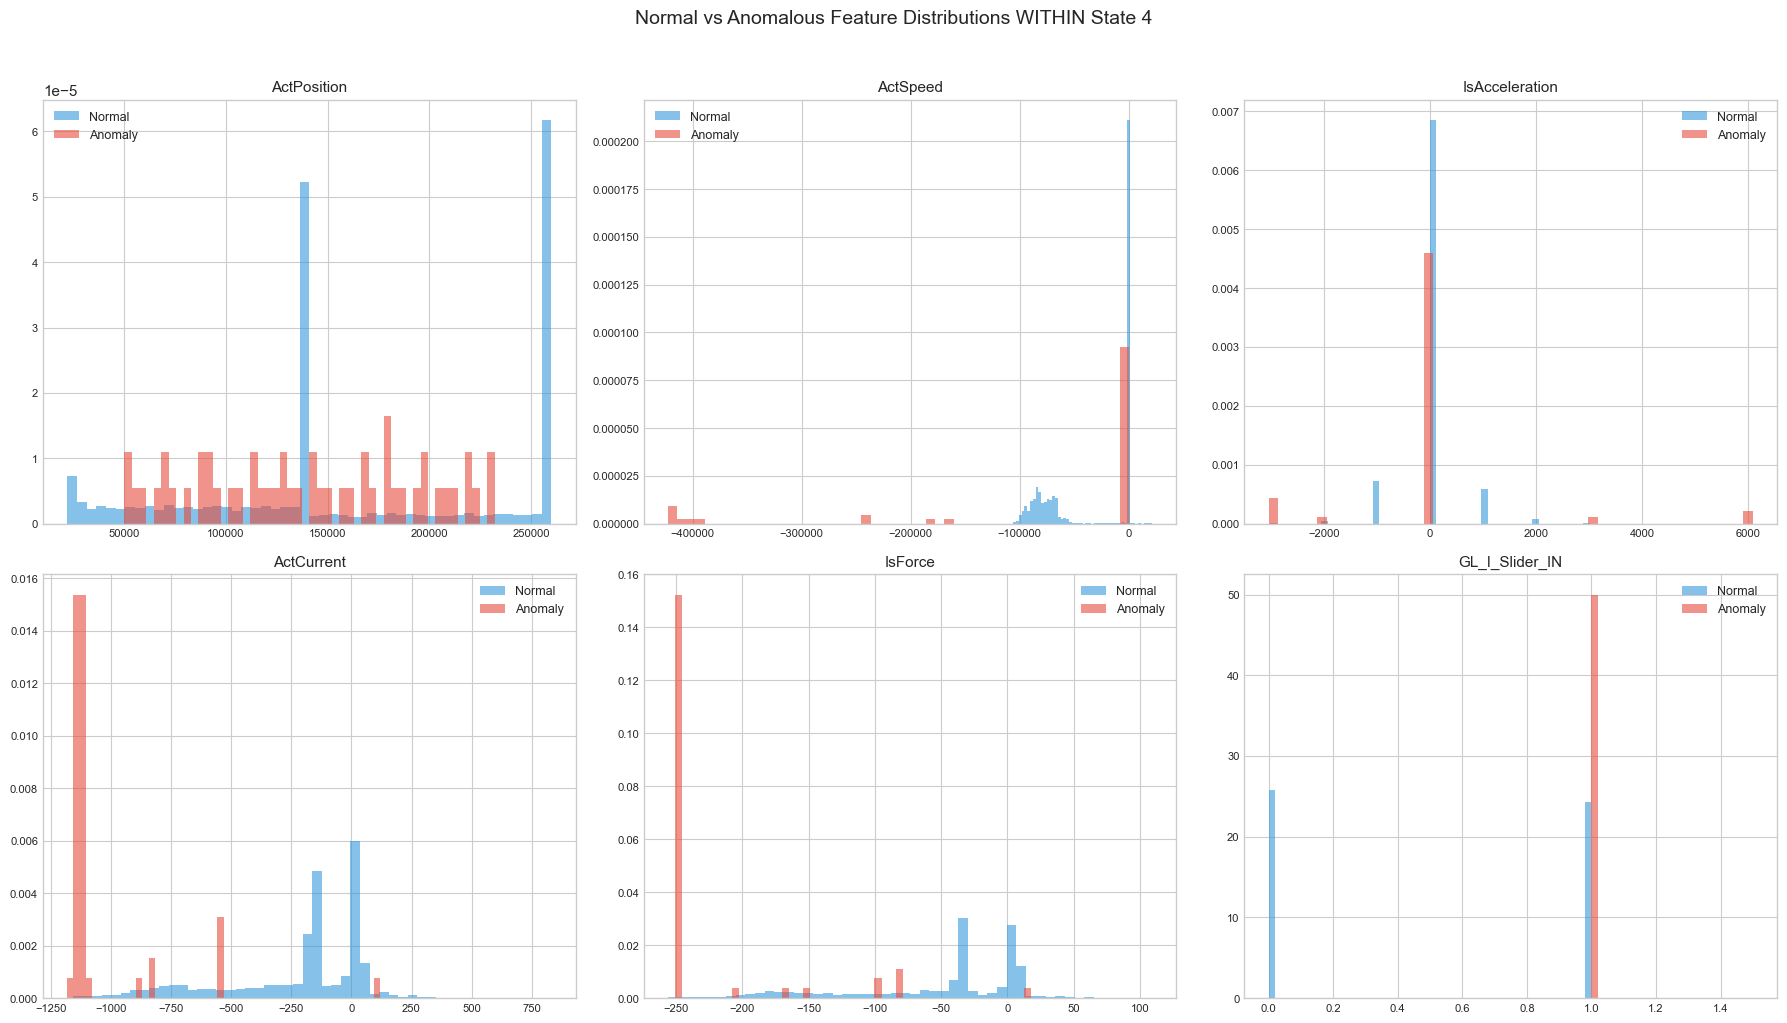


This shows that within a single operational phase (State 4),
anomalous samples have shifted or broadened distributions on certain features.
A good anomaly detector must distinguish these WITHIN-PHASE deviations.


In [13]:
# --- 8b: Overlay normal vs anomalous data within a specific phase ---
sensor_cols_anom = [c for c in anomaly_labels.columns if c not in ['Timestamp', 'Label']]

# Find the state with the highest anomaly rate (most interesting for visualization)
target_state = state_anomaly_rate.idxmax()

# Get indices for this state
state_mask = state_labels['Label'].values == target_state
normal_in_state = state_mask & (anomaly_labels['Label'].values == 0)
anomaly_in_state = state_mask & (anomaly_labels['Label'].values != 0)

print(f"Visualizing State {target_state} (highest anomaly rate: {state_anomaly_rate[target_state]:.1f}%)")
print(f"  Normal samples in this state: {normal_in_state.sum()}")
print(f"  Anomalous samples in this state: {anomaly_in_state.sum()}")

# Select features with most variance in this state for clearer visualization
state_data = anomaly_labels.loc[state_mask, sensor_cols_anom]
feat_variance = state_data.var().sort_values(ascending=False)
top_features = feat_variance.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    normal_vals = anomaly_labels.loc[normal_in_state, feat].values
    anomaly_vals = anomaly_labels.loc[anomaly_in_state, feat].values
    
    # Plot as overlapping histograms
    if len(normal_vals) > 0:
        ax.hist(normal_vals, bins=50, alpha=0.6, color='#3498db', label='Normal', density=True)
    if len(anomaly_vals) > 0:
        ax.hist(anomaly_vals, bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
    
    ax.set_title(feat.split('.')[-1][:20], fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Normal vs Anomalous Feature Distributions WITHIN State {target_state}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nThis shows that within a single operational phase (State {target_state}),")
print("anomalous samples have shifted or broadened distributions on certain features.")
print("A good anomaly detector must distinguish these WITHIN-PHASE deviations.")


## 9. Fault Progression Analysis (Early Detection)

Identifying **when a fault first becomes detectable** is the core challenge of early prediction. Genesis allows studying two different fault modes: **linear drive** (mechanical) and **pressure** (pneumatic). By comparing rolling statistics of normal vs faulty operation, we can identify the "divergence point" where trajectories separate -- this defines the theoretical limit of early detection.

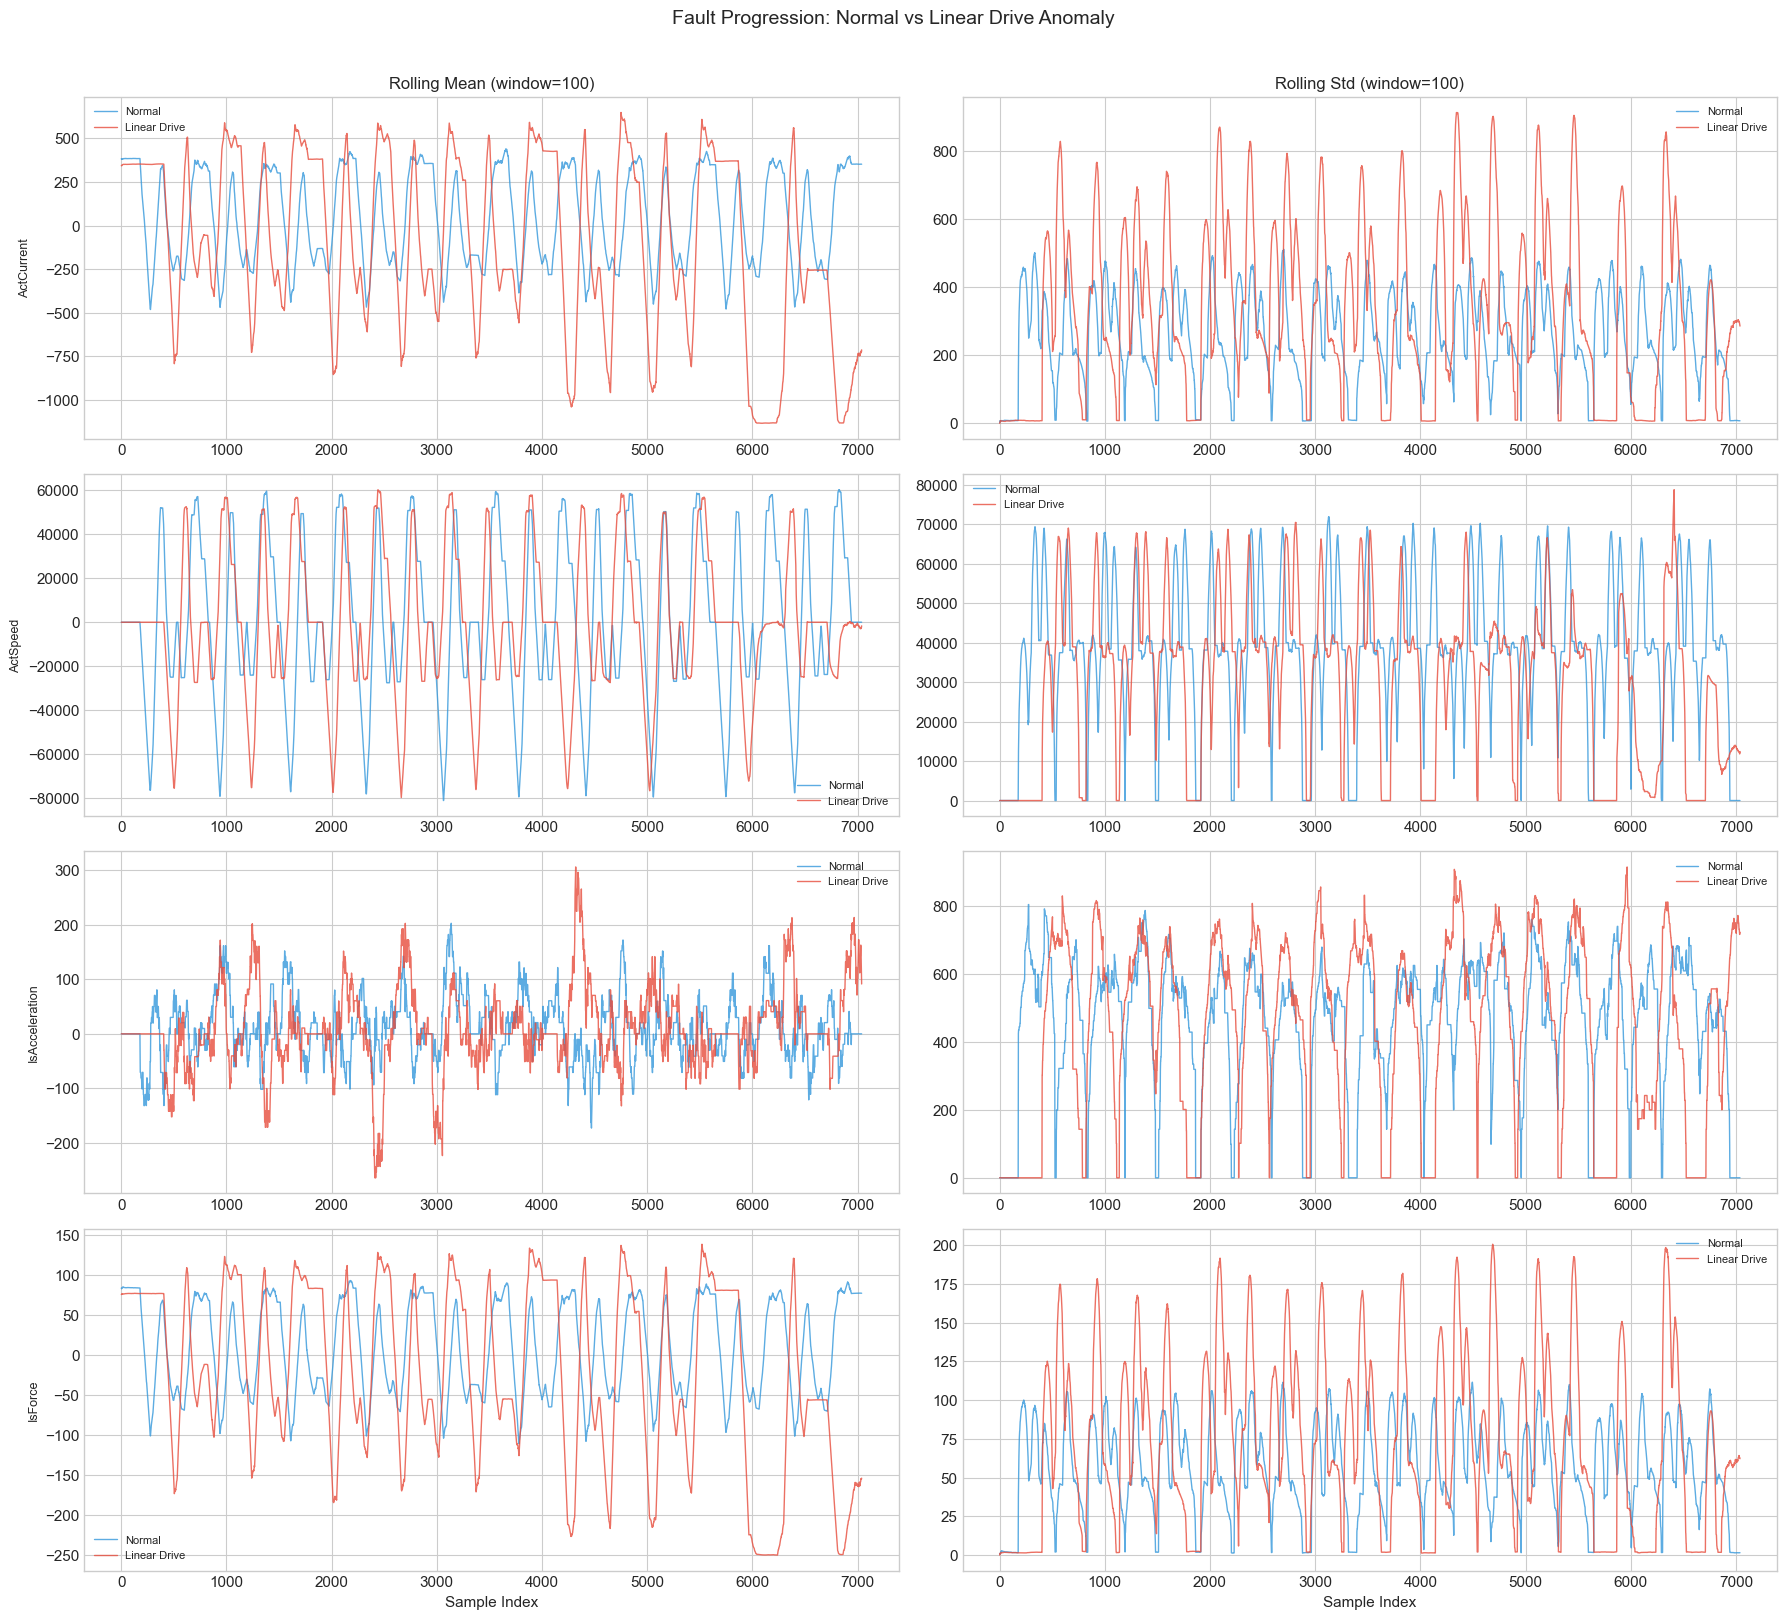

In [14]:
# --- 9a: Rolling statistics comparison — Normal vs Linear Drive anomaly ---
motor_features_common = [c for c in normal.columns if c != 'Timestamp' and c in lineardrive.columns]

# Select key motor features for fault analysis
key_motor = [c for c in motor_features_common if 'Motor' in c or 'Act' in c]
if len(key_motor) == 0:
    key_motor = motor_features_common[:4]
else:
    key_motor = key_motor[:4]

window = 100  # rolling window size

fig, axes = plt.subplots(len(key_motor), 2, figsize=(18, 4 * len(key_motor)))
if len(key_motor) == 1:
    axes = axes.reshape(1, -1)

min_len = min(len(normal), len(lineardrive))

for i, feat in enumerate(key_motor):
    normal_series = normal[feat].values[:min_len]
    anomaly_series = lineardrive[feat].values[:min_len]
    
    # Rolling mean
    normal_rmean = pd.Series(normal_series).rolling(window, min_periods=1).mean().values
    anomaly_rmean = pd.Series(anomaly_series).rolling(window, min_periods=1).mean().values
    
    # Rolling std
    normal_rstd = pd.Series(normal_series).rolling(window, min_periods=1).std().values
    anomaly_rstd = pd.Series(anomaly_series).rolling(window, min_periods=1).std().values
    
    # Plot rolling mean
    axes[i][0].plot(normal_rmean, linewidth=1, color='#3498db', label='Normal', alpha=0.8)
    axes[i][0].plot(anomaly_rmean, linewidth=1, color='#e74c3c', label='Linear Drive', alpha=0.8)
    axes[i][0].set_ylabel(feat.split('.')[-1][:15], fontsize=9)
    axes[i][0].legend(fontsize=8)
    if i == 0:
        axes[i][0].set_title(f'Rolling Mean (window={window})', fontsize=12)
    
    # Plot rolling std
    axes[i][1].plot(normal_rstd, linewidth=1, color='#3498db', label='Normal', alpha=0.8)
    axes[i][1].plot(anomaly_rstd, linewidth=1, color='#e74c3c', label='Linear Drive', alpha=0.8)
    axes[i][1].legend(fontsize=8)
    if i == 0:
        axes[i][1].set_title(f'Rolling Std (window={window})', fontsize=12)

axes[-1][0].set_xlabel('Sample Index')
axes[-1][1].set_xlabel('Sample Index')
plt.suptitle('Fault Progression: Normal vs Linear Drive Anomaly', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


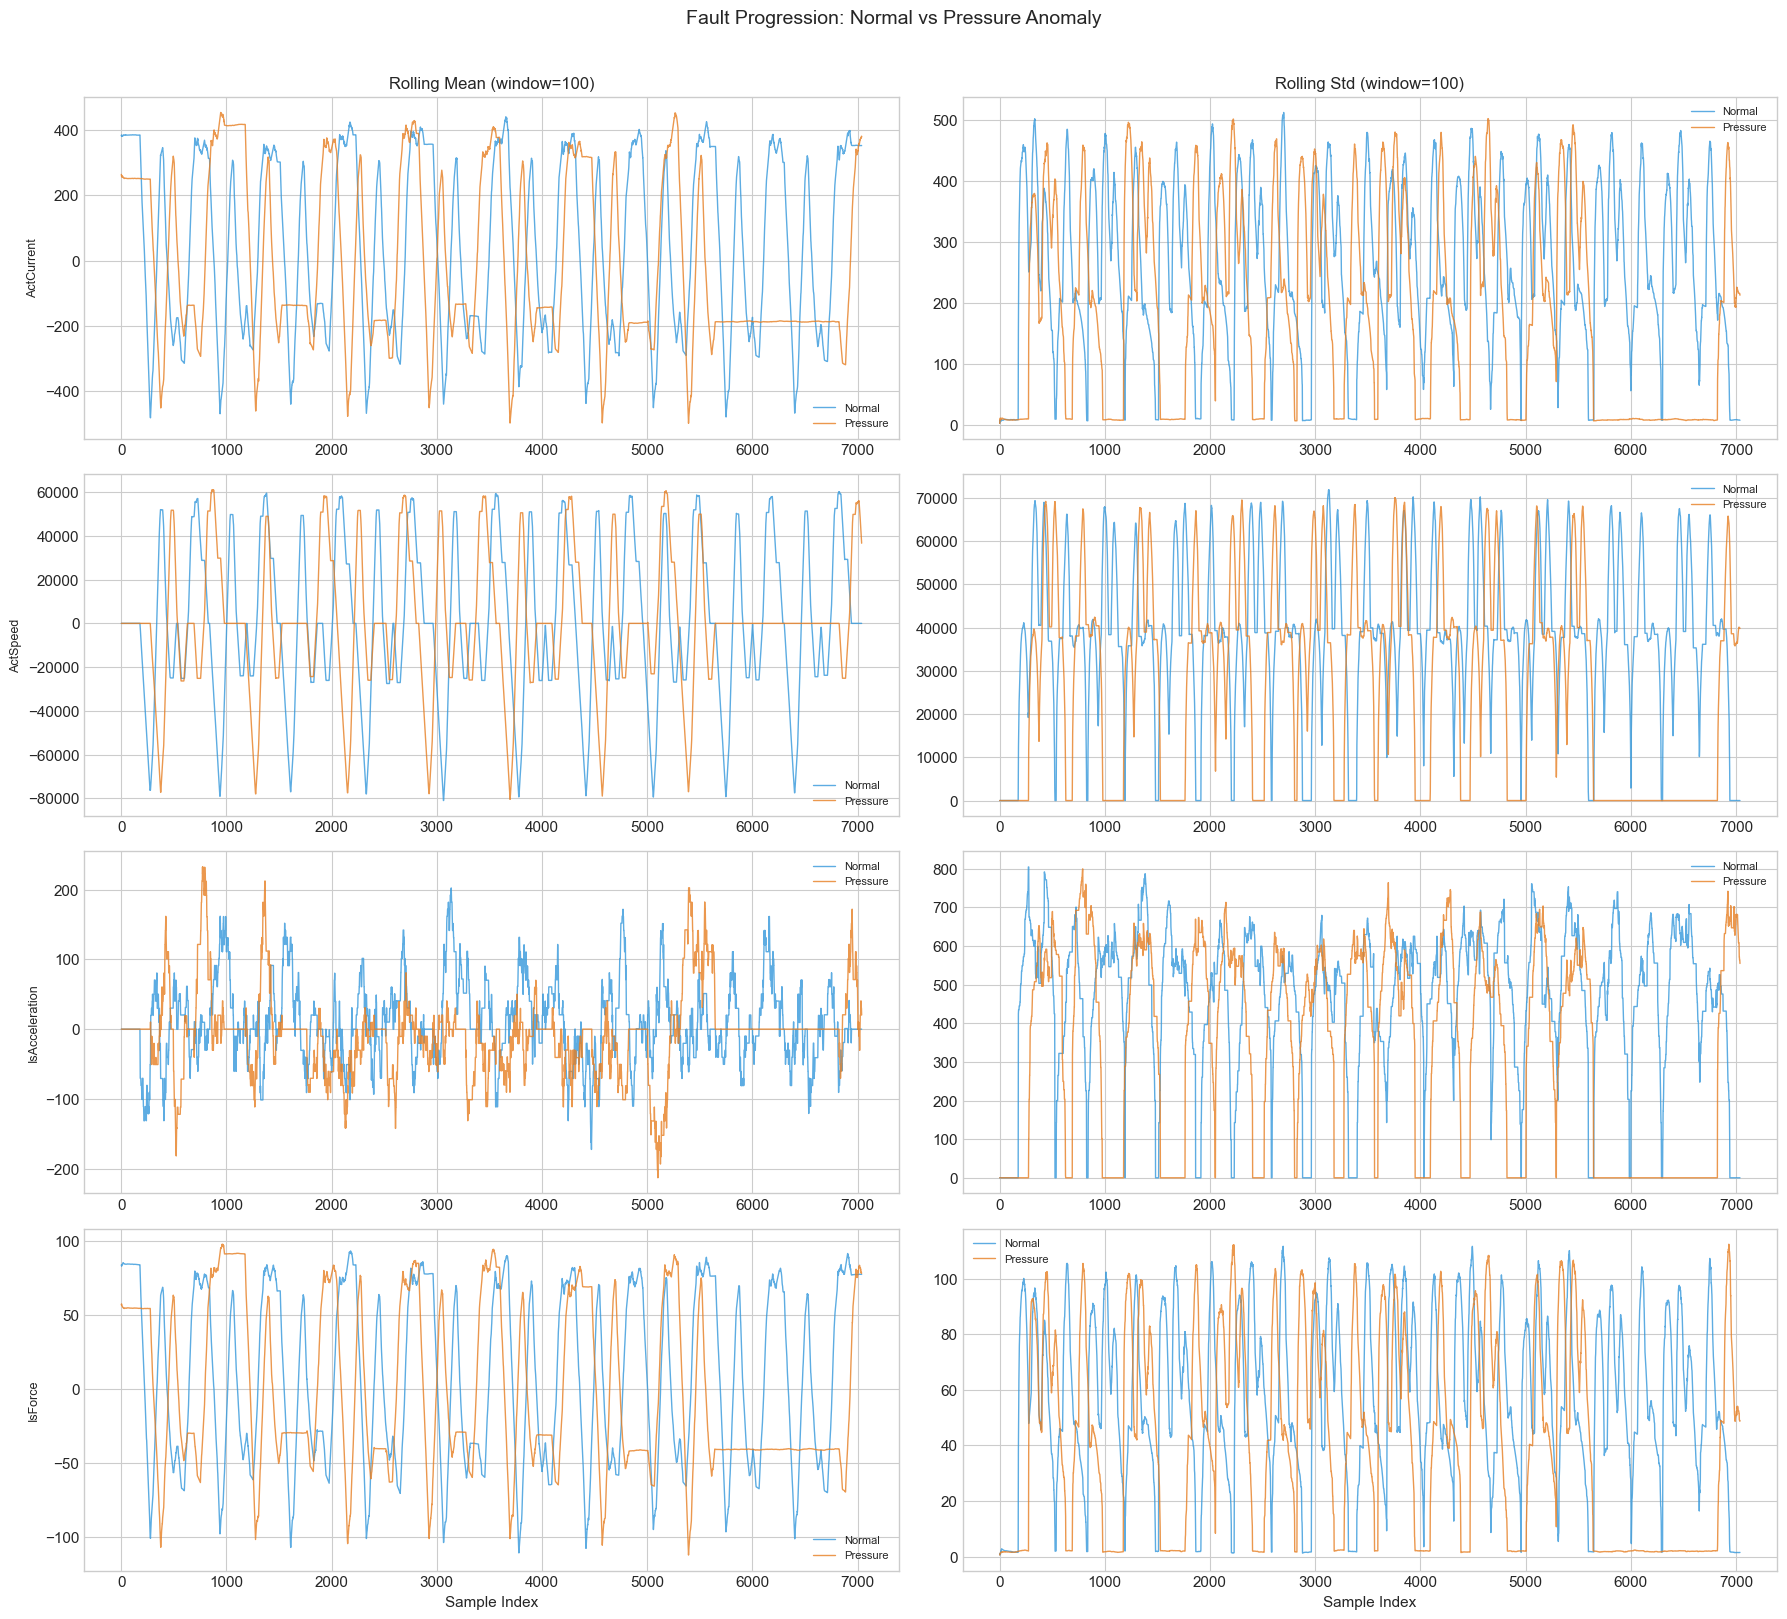

In [15]:
# --- 9b: Rolling statistics comparison — Normal vs Pressure anomaly ---
pressure_features_common = [c for c in normal.columns if c != 'Timestamp' and c in pressure.columns]

key_pressure = pressure_features_common[:4]

min_len_p = min(len(normal), len(pressure))

fig, axes = plt.subplots(len(key_pressure), 2, figsize=(18, 4 * len(key_pressure)))
if len(key_pressure) == 1:
    axes = axes.reshape(1, -1)

for i, feat in enumerate(key_pressure):
    normal_series = normal[feat].values[:min_len_p]
    anomaly_series = pressure[feat].values[:min_len_p]
    
    normal_rmean = pd.Series(normal_series).rolling(window, min_periods=1).mean().values
    anomaly_rmean = pd.Series(anomaly_series).rolling(window, min_periods=1).mean().values
    normal_rstd = pd.Series(normal_series).rolling(window, min_periods=1).std().values
    anomaly_rstd = pd.Series(anomaly_series).rolling(window, min_periods=1).std().values
    
    axes[i][0].plot(normal_rmean, linewidth=1, color='#3498db', label='Normal', alpha=0.8)
    axes[i][0].plot(anomaly_rmean, linewidth=1, color='#e67e22', label='Pressure', alpha=0.8)
    axes[i][0].set_ylabel(feat.split('.')[-1][:15], fontsize=9)
    axes[i][0].legend(fontsize=8)
    if i == 0:
        axes[i][0].set_title(f'Rolling Mean (window={window})', fontsize=12)
    
    axes[i][1].plot(normal_rstd, linewidth=1, color='#3498db', label='Normal', alpha=0.8)
    axes[i][1].plot(anomaly_rstd, linewidth=1, color='#e67e22', label='Pressure', alpha=0.8)
    axes[i][1].legend(fontsize=8)
    if i == 0:
        axes[i][1].set_title(f'Rolling Std (window={window})', fontsize=12)

axes[-1][0].set_xlabel('Sample Index')
axes[-1][1].set_xlabel('Sample Index')
plt.suptitle('Fault Progression: Normal vs Pressure Anomaly', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


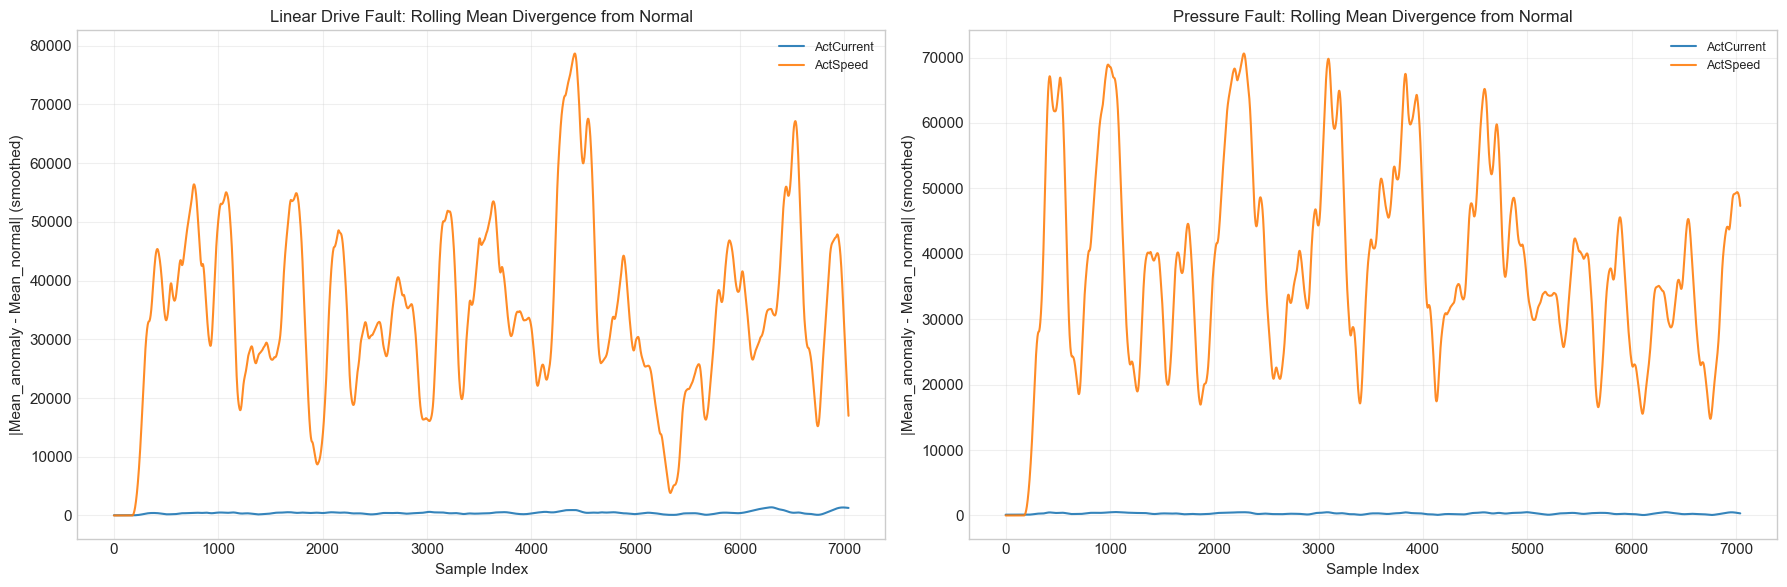

Divergence curves show when the fault signature becomes statistically distinguishable.
A sharp rise indicates the fault onset; gradual rise suggests progressive degradation.
Early prediction methods aim to detect faults BEFORE the divergence becomes large.


In [16]:
# --- 9c: Divergence point detection ---
# Compute cumulative absolute difference between normal and anomaly rolling means
# to find where the fault signal first becomes distinguishable

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Linear drive divergence
for feat in key_motor[:2]:
    normal_series = normal[feat].values[:min_len]
    anomaly_series = lineardrive[feat].values[:min_len]
    
    normal_rmean = pd.Series(normal_series).rolling(window, min_periods=1).mean().values
    anomaly_rmean = pd.Series(anomaly_series).rolling(window, min_periods=1).mean().values
    
    # Absolute difference of rolling means
    diff = np.abs(anomaly_rmean - normal_rmean)
    # Smooth the difference for clearer visualization
    diff_smooth = pd.Series(diff).rolling(window * 2, min_periods=1).mean().values
    
    axes[0].plot(diff_smooth, linewidth=1.5, label=feat.split('.')[-1][:15], alpha=0.9)

# Add a threshold line (2 * median of first 500 points as baseline)
axes[0].set_title('Linear Drive Fault: Rolling Mean Divergence from Normal', fontsize=12)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('|Mean_anomaly - Mean_normal| (smoothed)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Pressure divergence
for feat in key_pressure[:2]:
    normal_series = normal[feat].values[:min_len_p]
    anomaly_series = pressure[feat].values[:min_len_p]
    
    normal_rmean = pd.Series(normal_series).rolling(window, min_periods=1).mean().values
    anomaly_rmean = pd.Series(anomaly_series).rolling(window, min_periods=1).mean().values
    
    diff = np.abs(anomaly_rmean - normal_rmean)
    diff_smooth = pd.Series(diff).rolling(window * 2, min_periods=1).mean().values
    
    axes[1].plot(diff_smooth, linewidth=1.5, label=feat.split('.')[-1][:15], alpha=0.9)

axes[1].set_title('Pressure Fault: Rolling Mean Divergence from Normal', fontsize=12)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('|Mean_anomaly - Mean_normal| (smoothed)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Divergence curves show when the fault signature becomes statistically distinguishable.")
print("A sharp rise indicates the fault onset; gradual rise suggests progressive degradation.")
print("Early prediction methods aim to detect faults BEFORE the divergence becomes large.")


## 10. Dataset Suitability Assessment

### Research Task Suitability Scores

| Research Task | Suitability | Score | Justification |
|---|---|---|---|
| **MTS Clustering** | Excellent | 5/5 | State machine labels (9 states) provide **perfect ground truth** for temporal segmentation. The cyclic pick-and-place process creates well-defined, repeating operational phases. TICC should recover these phases from raw sensor data. Transition matrix reveals deterministic cycle structure. |
| **Unsupervised Anomaly Detection** | Good | 4/5 | Clear binary anomaly labels enable evaluation. Two distinct fault modes (linear drive + pressure) allow multi-class detection. Physical sensor data with realistic noise. Limitation: moderate dataset size (~16K samples) and only 18 features may limit deep learning approaches. |
| **Early Detection / RUL** | Moderate | 3/5 | Two fault types with separate data files allow studying fault progression. Rolling statistics reveal divergence patterns. However, the dataset does not provide explicit degradation trajectories or time-to-failure labels, limiting direct RUL estimation. Better suited for early fault detection than lifetime prediction. |

### Key Strengths
- **Ground truth clustering labels**: The 9-state machine labels are rare among MTS benchmark datasets -- most datasets lack explicit operational phase labels
- **Multiple fault modes**: Linear drive (mechanical) and pressure (pneumatic) anomalies enable studying how different fault types manifest differently in sensor space
- **Physical realism**: Data from a real pick-and-place demonstrator, not synthetic -- captures genuine sensor noise, actuator dynamics, and process variability
- **Cyclic process structure**: The repeating pick-and-place cycle creates natural periodicity that clustering methods can exploit
- **Compact but complete**: 18 features and ~16K samples per file make it computationally accessible while retaining multivariate complexity

### Key Limitations
- **Moderate scale**: Smaller than datasets like SMD (28 machines) or SWaT (51 features, 946K samples) -- may not stress-test scalability
- **No explicit RUL labels**: Fault files show anomalous operation but lack degradation progression timestamps or remaining-useful-life annotations
- **Binary anomaly labels**: Only normal vs anomaly (labels 0/1/2), no fine-grained fault severity or fault type annotations in the main label file
- **Single machine**: All data from one demonstrator -- no multi-entity generalization possible

### Concrete Next Steps
1. **Clustering**: Apply TICC with K=9 to the state_labels sensor data (excluding the Label column). Evaluate with ARI/NMI against the 9 state machine labels. Experiment with different window sizes to find optimal temporal granularity.
2. **Anomaly Detection**: Train an autoencoder/VAE on normal operation data only. Evaluate reconstruction error on the anomaly_labels file. Compare detection performance across operational phases (Section 8 showed non-uniform anomaly distribution).
3. **Early Detection**: Define a sliding window approach on the lineardrive and pressure files. Use the divergence analysis from Section 9 to establish detection thresholds. Study how early a simple threshold detector can catch faults vs a learned model.
4. **Cross-task Integration**: Use clustering results to build phase-aware anomaly detectors (different thresholds per operational phase). This leverages Genesis's unique combination of state labels + anomaly labels.